First Iteration of code to calculate RPM from some known engine values and constants.

In [1]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# ---------------------------
# Load + normalize audio
# ---------------------------
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


# ---------------------------
# Select steady-state region
# ---------------------------
def select_steady_state_segment(x, sr, choose_sec=6.0):
    frame_len = int(1.0 * sr)
    hop_len = int(0.25 * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x

    starts = np.arange(0, len(x) - frame_len, hop_len)

    rms_vals = []
    centroid_vals = []

    for s in starts:
        frame = x[s:s + frame_len]
        rms = np.sqrt(np.mean(frame**2))

        freqs, psd = sig.welch(frame, fs=sr, nperseg=min(4096, len(frame)))
        centroid = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0

        rms_vals.append(rms)
        centroid_vals.append(centroid)

    rms_vals = np.array(rms_vals)
    centroid_vals = np.array(centroid_vals)

    best_score = np.inf
    best_start = 0

    window = int(choose_sec / 0.25)

    for i in range(len(starts) - window):
        score = np.std(rms_vals[i:i+window]) + 0.001 * np.std(centroid_vals[i:i+window])
        if score < best_score:
            best_score = score
            best_start = starts[i]

    return x[best_start:best_start + choose_len]


# ---------------------------
# Bandpass filter
# ---------------------------
def bandpass_filter(x, sr, low=20, high=1200):
    sos = sig.butter(6, [low, high], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


# ---------------------------
# Power spectrum
# ---------------------------
def welch_spectrum(x, sr):
    nperseg = min(32768, len(x))
    f, pxx = sig.welch(x, fs=sr, nperseg=nperseg)
    return f, pxx


# ---------------------------
# Harmonic detection (KEY PART)
# ---------------------------
def harmonic_sum_score(freqs, power, fmin=10, fmax=150):
    candidates = np.arange(fmin, fmax, 0.1)
    scores = []

    for f0 in candidates:
        score = 0
        weight_sum = 0

        for k in range(1, 8):
            fk = k * f0
            if fk > freqs[-1]:
                break

            idx = np.argmin(np.abs(freqs - fk))
            w = 1 / k
            score += w * power[idx]
            weight_sum += w

        scores.append(score / weight_sum if weight_sum > 0 else 0)

    scores = np.array(scores)
    best_idx = np.argmax(scores)

    return candidates[best_idx], scores


# ---------------------------
# Cepstrum check (advanced validation)
# ---------------------------
def cepstrum_check(x, sr):
    n = min(len(x), 65536)
    x = x[:n] * np.hanning(n)

    spec = np.abs(np.fft.rfft(x)) + 1e-12
    ceps = np.fft.irfft(np.log(spec))

    quef = np.arange(len(ceps)) / sr

    mask = (quef > 1/150) & (quef < 1/10)

    if np.any(mask):
        q_peak = quef[mask][np.argmax(ceps[mask])]
        return 1 / q_peak

    return None


# ---------------------------
# MAIN FUNCTION
# ---------------------------
def estimate_rpm_from_wav(wav_path, cylinders=4, strokes=4):

    sr, x = load_wav_mono(wav_path)

    # Step 1: steady-state
    x = select_steady_state_segment(x, sr)

    # Step 2: filter
    x = bandpass_filter(x, sr)

    # Step 3: spectrum
    freqs, pxx = welch_spectrum(x, sr)

    mask = (freqs >= 10) & (freqs <= 300)
    freqs = freqs[mask]
    pxx = pxx[mask]

    # Step 4: harmonic detection
    f_detected, scores = harmonic_sum_score(freqs, pxx)

    # Step 5: cepstrum validation
    f_cep = cepstrum_check(x, sr)

    # Step 6: RPM calculations
    rpm_direct = 60 * f_detected

    if strokes == 4:
        rpm_engine = (120 * f_detected) / cylinders
    else:
        rpm_engine = (60 * f_detected) / cylinders

    return {
    "Detected Frequency (Hz)": round(float(f_detected), 2),
    "Cepstrum Check (Hz)": round(float(f_cep), 2) if f_cep is not None else None,
    "RPM (direct)": round(float(rpm_direct), 0),
    "RPM (engine model)": round(float(rpm_engine), 0)
}

In [2]:
result = estimate_rpm_from_wav(
    "ToyotaRav4_3000RPM.wav",
    cylinders=4,
    strokes=4
)

result

{'Detected Frequency (Hz)': 106.3,
 'Cepstrum Check (Hz)': 22.49,
 'RPM (direct)': 6378.0,
 'RPM (engine model)': 3189.0}

In [2]:
result = estimate_rpm_from_wav(
    "BMW_4000_RPM.wav",
    cylinders=4,
    strokes=4
)

result

{'Detected Frequency (Hz)': 122.2,
 'Cepstrum Check (Hz)': 31.64,
 'RPM (direct)': 7332.0,
 'RPM (engine model)': 3666.0}

Second Iteration of code to calculate Max RPM from audio file with known engin

In [3]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# ---------------------------
# Load + normalize audio
# ---------------------------
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


# ---------------------------
# Bandpass filter
# ---------------------------
def bandpass_filter(x, sr, low=20, high=1200):
    sos = sig.butter(6, [low, high], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


# ---------------------------
# Power spectrum
# ---------------------------
def welch_spectrum(x, sr):
    nperseg = min(32768, len(x))
    f, pxx = sig.welch(x, fs=sr, nperseg=nperseg)
    return f, pxx


# ---------------------------
# Harmonic detection
# ---------------------------
def harmonic_sum_score(freqs, power, fmin=10, fmax=150):
    candidates = np.arange(fmin, fmax, 0.1)
    scores = []

    for f0 in candidates:
        score = 0.0
        weight_sum = 0.0

        for k in range(1, 8):
            fk = k * f0
            if fk > freqs[-1]:
                break

            idx = np.argmin(np.abs(freqs - fk))
            w = 1 / k
            score += w * power[idx]
            weight_sum += w

        scores.append(score / weight_sum if weight_sum > 0 else 0.0)

    scores = np.array(scores)
    best_idx = np.argmax(scores)

    return candidates[best_idx], scores[best_idx]


# ---------------------------
# Cepstrum check
# ---------------------------
def cepstrum_check(x, sr):
    n = min(len(x), 65536)
    x = x[:n] * np.hanning(n)

    spec = np.abs(np.fft.rfft(x)) + 1e-12
    ceps = np.fft.irfft(np.log(spec))

    quef = np.arange(len(ceps)) / sr
    mask = (quef > 1/150) & (quef < 1/10)

    if np.any(mask):
        q_peak = quef[mask][np.argmax(ceps[mask])]
        return 1 / q_peak

    return None


# ---------------------------
# Estimate RPM on one segment
# ---------------------------
def estimate_rpm_segment(x_seg, sr, cylinders=4, strokes=4, fmin=10, fmax=300):
    if len(x_seg) < int(1.0 * sr):
        return None

    x_seg = bandpass_filter(x_seg, sr)

    freqs, pxx = welch_spectrum(x_seg, sr)

    mask = (freqs >= fmin) & (freqs <= fmax)
    freqs = freqs[mask]
    pxx = pxx[mask]

    if len(freqs) == 0 or np.all(pxx <= 0):
        return None

    f_detected, best_score = harmonic_sum_score(freqs, pxx, fmin=fmin, fmax=min(fmax, 150))
    f_cep = cepstrum_check(x_seg, sr)

    rpm_direct = 60 * f_detected

    if strokes == 4:
        rpm_engine = (120 * f_detected) / cylinders
    else:
        rpm_engine = (60 * f_detected) / cylinders

    return {
        "freq_hz": float(f_detected),
        "cepstrum_hz": float(f_cep) if f_cep is not None else None,
        "rpm_direct": float(rpm_direct),
        "rpm_engine": float(rpm_engine),
        "score": float(best_score),
    }


# ---------------------------
# Scan whole WAV for max RPM
# ---------------------------
def estimate_max_rpm_from_wav(
    wav_path,
    cylinders=4,
    strokes=4,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10,
    fmax=300,
    use_engine_model=True,
):
    sr, x = load_wav_mono(wav_path)

    win_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)

    results = []

    for start in range(0, len(x) - win_len + 1, hop_len):
        x_seg = x[start:start + win_len]

        result = estimate_rpm_segment(
            x_seg,
            sr,
            cylinders=cylinders,
            strokes=strokes,
            fmin=fmin,
            fmax=fmax,
        )

        if result is None:
            continue

        result["start_sec"] = start / sr
        result["end_sec"] = (start + win_len) / sr
        results.append(result)

    if not results:
        return {"error": "No valid RPM estimates found."}

    rpm_key = "rpm_engine" if use_engine_model else "rpm_direct"
    best = max(results, key=lambda r: r[rpm_key])

    return {
        "Max RPM": round(best[rpm_key]),
        "Model Used": "engine model" if use_engine_model else "direct",
        "At Time (s)": round(best["start_sec"], 2),
        "Window End (s)": round(best["end_sec"], 2),
        "Detected Frequency (Hz)": round(best["freq_hz"], 2),
        "Cepstrum Check (Hz)": round(best["cepstrum_hz"], 2) if best["cepstrum_hz"] is not None else None,
        "All Window Results": results,
    }

In [7]:
result = estimate_max_rpm_from_wav(
    "BMW_4000_RPM.wav",
    cylinders=4,
    strokes=4,
    window_sec=2.0,
    hop_sec=0.5,
    use_engine_model=True
)

print(result["Max RPM"])
print(result["At Time (s)"])

3909
5.0


3rd Iteration of code to find RPM without known engine specs, attempting to estimate RPM based off frequency

In [1]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


def select_steady_state_segment(x, sr, window_sec=2.0, hop_sec=0.5, choose_sec=6.0):
    frame_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x

    starts = np.arange(0, len(x) - frame_len + 1, hop_len)
    rms_vals = []
    centroid_vals = []

    for s in starts:
        frame = x[s:s + frame_len]
        rms = np.sqrt(np.mean(frame**2))

        freqs, psd = sig.welch(frame, fs=sr, nperseg=min(4096, len(frame)))
        if np.sum(psd) > 0:
            centroid = np.sum(freqs * psd) / np.sum(psd)
        else:
            centroid = 0.0

        rms_vals.append(rms)
        centroid_vals.append(centroid)

    rms_vals = np.array(rms_vals)
    centroid_vals = np.array(centroid_vals)

    choose_frames = max(1, int(np.ceil((choose_sec - window_sec) / hop_sec)) + 1)

    best_score = np.inf
    best_start = starts[0]

    for i in range(0, len(starts) - choose_frames + 1):
        j = i + choose_frames
        score = np.std(rms_vals[i:j]) + 0.001 * np.std(centroid_vals[i:j])
        if score < best_score:
            best_score = score
            best_start = starts[i]

    return x[best_start:best_start + choose_len]


def bandpass_filter(x, sr, low_hz=20.0, high_hz=1500.0):
    sos = sig.butter(6, [low_hz, high_hz], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


def welch_spectrum(x, sr, nperseg=32768):
    nperseg = min(nperseg, len(x))
    if nperseg < 1024:
        nperseg = len(x)

    noverlap = nperseg // 2
    f, pxx = sig.welch(
        x,
        fs=sr,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="spectrum"
    )
    return f, pxx


def cepstrum_candidates(x, sr, fmin=8.0, fmax=200.0, top_n=5):
    n = min(len(x), 131072)
    if n < 2048:
        return []

    xw = x[:n] * np.hanning(n)
    spec = np.abs(np.fft.rfft(xw)) + 1e-12
    ceps = np.fft.irfft(np.log(spec))
    quef = np.arange(len(ceps)) / sr

    qmin = 1.0 / fmax
    qmax = 1.0 / fmin
    mask = (quef >= qmin) & (quef <= qmax)

    q = quef[mask]
    c = ceps[mask]

    if len(c) < 3:
        return []

    peaks, _ = sig.find_peaks(c, distance=max(1, len(c)//50))
    if len(peaks) == 0:
        return []

    peak_vals = c[peaks]
    order = np.argsort(peak_vals)[::-1][:top_n]

    freqs = []
    for idx in order:
        q_peak = q[peaks[idx]]
        if q_peak > 0:
            freqs.append(1.0 / q_peak)

    return freqs


def harmonic_score_for_f0(freqs, power, f0, max_harmonics=10, tol_hz=1.5):
    score = 0.0
    matched = 0
    total_weight = 0.0

    for k in range(1, max_harmonics + 1):
        fk = k * f0
        if fk > freqs[-1]:
            break

        idx = np.argmin(np.abs(freqs - fk))
        err = abs(freqs[idx] - fk)

        w = 1.0 / k
        total_weight += w

        if err <= tol_hz:
            score += w * power[idx]
            matched += 1

    if total_weight == 0:
        return 0.0, 0

    return score / total_weight, matched


def infer_fundamental_from_peaks(freqs, power, fmin=8.0, fmax=200.0):
    peaks, props = sig.find_peaks(power, prominence=np.max(power) * 0.03)
    if len(peaks) == 0:
        return None, 0.0

    peak_freqs = freqs[peaks]
    peak_power = power[peaks]

    valid = (peak_freqs >= fmin) & (peak_freqs <= min(fmax * 10, freqs[-1]))
    peak_freqs = peak_freqs[valid]
    peak_power = peak_power[valid]

    if len(peak_freqs) == 0:
        return None, 0.0

    top_order = np.argsort(peak_power)[::-1][:15]
    top_freqs = peak_freqs[top_order]

    candidate_set = set()

    for f in top_freqs:
        for d in [1, 2, 3, 4, 5, 6]:
            cand = f / d
            if fmin <= cand <= fmax:
                candidate_set.add(round(cand, 2))

    candidates = sorted(candidate_set)

    best_f0 = None
    best_score = -np.inf
    best_matched = -1

    for f0 in candidates:
        score, matched = harmonic_score_for_f0(freqs, power, f0)
        if (matched > best_matched) or (matched == best_matched and score > best_score):
            best_score = score
            best_matched = matched
            best_f0 = f0

    confidence = float(best_score) if np.isfinite(best_score) else 0.0
    return best_f0, confidence


def estimate_rpm_audio_only(
    wav_path,
    low_hz=20.0,
    high_hz=1500.0,
    candidate_fmin=8.0,
    candidate_fmax=200.0,
    window_sec=2.0,
    hop_sec=0.5,
    choose_sec=6.0,
):
    sr, x = load_wav_mono(wav_path)

    x_seg = select_steady_state_segment(
        x, sr,
        window_sec=window_sec,
        hop_sec=hop_sec,
        choose_sec=choose_sec
    )

    x_bp = bandpass_filter(x_seg, sr, low_hz=low_hz, high_hz=high_hz)

    freqs, pxx = welch_spectrum(x_bp, sr)
    mask = (freqs >= candidate_fmin) & (freqs <= max(candidate_fmax * 10, high_hz))
    freqs_use = freqs[mask]
    pxx_use = pxx[mask]

    f0_peak, conf_peak = infer_fundamental_from_peaks(
        freqs_use, pxx_use,
        fmin=candidate_fmin,
        fmax=candidate_fmax
    )

    cep_candidates = cepstrum_candidates(
        x_bp, sr,
        fmin=candidate_fmin,
        fmax=candidate_fmax,
        top_n=5
    )

    f0_final = f0_peak
    cep_match = None

    if f0_peak is not None and len(cep_candidates) > 0:
        diffs = [abs(c - f0_peak) for c in cep_candidates]
        best_i = int(np.argmin(diffs))
        cep_match = cep_candidates[best_i]

        # If cepstrum strongly supports a nearby lower fundamental, prefer it
        if abs(cep_match - f0_peak) / max(f0_peak, 1e-9) < 0.20:
            f0_final = min(f0_peak, cep_match)

    if f0_final is None and len(cep_candidates) > 0:
        f0_final = cep_candidates[0]

    if f0_final is None:
        raise ValueError("Could not infer a reliable periodic frequency from this audio.")

    rpm_est = 60.0 * f0_final

    return {
        "estimated_fundamental_hz": round(float(f0_final), 2),
        "estimated_rpm": round(float(rpm_est), 1),
        "peak_model_f0_hz": round(float(f0_peak), 2) if f0_peak is not None else None,
        "cepstrum_supported_hz": round(float(cep_match), 2) if cep_match is not None else None,
        "confidence_proxy": round(float(conf_peak), 6),
        "note": "Audio-only estimate. Exact RPM may remain ambiguous for unknown machine architecture."
    }

In [2]:
result = estimate_rpm_audio_only("ToyotaRav4_3000RPM.wav")
result

{'estimated_fundamental_hz': 106.93,
 'estimated_rpm': 6415.8,
 'peak_model_f0_hz': 106.93,
 'cepstrum_supported_hz': 26.13,
 'confidence_proxy': 1.6e-05,
 'note': 'Audio-only estimate. Exact RPM may remain ambiguous for unknown machine architecture.'}

4th Iteration of code to find RPM without known engine specs, attempting to estimate RPM based off frequency

In [7]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# ---------------------------
# Load + normalize audio
# ---------------------------
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


# ---------------------------
# Select steady-state region
# ---------------------------
def select_steady_state_segment(x, sr, choose_sec=8.0):
    frame_len = int(1.0 * sr)
    hop_len = int(0.25 * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x, 0.0

    starts = np.arange(0, len(x) - frame_len, hop_len)

    rms_vals = []
    centroid_vals = []

    for s in starts:
        frame = x[s:s + frame_len]
        rms = np.sqrt(np.mean(frame**2))

        freqs, psd = sig.welch(frame, fs=sr, nperseg=min(4096, len(frame)))
        centroid = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0.0

        rms_vals.append(rms)
        centroid_vals.append(centroid)

    rms_vals = np.array(rms_vals)
    centroid_vals = np.array(centroid_vals)

    best_score = np.inf
    best_start = 0

    window = int(choose_sec / 0.25)

    for i in range(len(starts) - window):
        score = np.std(rms_vals[i:i+window]) + 0.001 * np.std(centroid_vals[i:i+window])
        if score < best_score:
            best_score = score
            best_start = starts[i]

    return x[best_start:best_start + choose_len], best_start / sr


# ---------------------------
# Bandpass filter
# ---------------------------
def bandpass_filter(x, sr, low=20, high=1200):
    sos = sig.butter(6, [low, high], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


# ---------------------------
# Power spectrum
# ---------------------------
def welch_spectrum(x, sr, nperseg=32768):
    nperseg = min(nperseg, len(x))
    if nperseg < 1024:
        nperseg = len(x)
    f, pxx = sig.welch(x, fs=sr, nperseg=nperseg)
    return f, pxx


# ---------------------------
# Harmonic detection
# ---------------------------
def harmonic_sum_score(freqs, power, fmin=10, fmax=150, max_harmonics=8):
    candidates = np.arange(fmin, fmax, 0.1)
    scores = []

    for f0 in candidates:
        score = 0.0
        weight_sum = 0.0

        for k in range(1, max_harmonics + 1):
            fk = k * f0
            if fk > freqs[-1]:
                break

            idx = np.argmin(np.abs(freqs - fk))
            w = 1 / k
            score += w * power[idx]
            weight_sum += w

        scores.append(score / weight_sum if weight_sum > 0 else 0.0)

    scores = np.array(scores)
    best_idx = np.argmax(scores)

    return candidates[best_idx], scores, candidates


# ---------------------------
# Cepstrum check
# ---------------------------
def cepstrum_check(x, sr):
    n = min(len(x), 65536)
    if n < 2048:
        return None

    x = x[:n] * np.hanning(n)

    spec = np.abs(np.fft.rfft(x)) + 1e-12
    ceps = np.fft.irfft(np.log(spec))
    quef = np.arange(len(ceps)) / sr

    mask = (quef > 1/150) & (quef < 1/10)

    if np.any(mask):
        q_peak = quef[mask][np.argmax(ceps[mask])]
        return 1 / q_peak

    return None


# ---------------------------
# Analyze one window using original logic
# ---------------------------
def analyze_window(window_x, sr, cylinders=4, strokes=4):
    x = bandpass_filter(window_x, sr)

    freqs, pxx = welch_spectrum(x, sr, nperseg=min(16384, len(x)))

    mask = (freqs >= 10) & (freqs <= 300)
    freqs = freqs[mask]
    pxx = pxx[mask]

    if len(freqs) < 10 or np.max(pxx) <= 0:
        return None

    f_detected, scores, candidates = harmonic_sum_score(freqs, pxx, fmin=10, fmax=150, max_harmonics=8)
    f_cep = cepstrum_check(x, sr)

    rpm_direct = 60 * f_detected

    if strokes == 4:
        rpm_engine = (120 * f_detected) / cylinders
    else:
        rpm_engine = (60 * f_detected) / cylinders

    # confidence proxy: separation from second-best score
    sorted_scores = np.sort(scores)
    second_best = sorted_scores[-2] if len(sorted_scores) > 1 else sorted_scores[-1]
    confidence_ratio = float(np.max(scores) / (second_best + 1e-12))

    # harmonic count estimate
    matched_harmonics = 0
    tol_hz = 1.5
    for k in range(1, 9):
        fk = k * f_detected
        if fk > freqs[-1]:
            break
        idx = np.argmin(np.abs(freqs - fk))
        if abs(freqs[idx] - fk) <= tol_hz:
            matched_harmonics += 1

    return {
        "detected_frequency_hz": float(f_detected),
        "cepstrum_hz": float(f_cep) if f_cep is not None else None,
        "rpm_direct": float(rpm_direct),
        "rpm_engine_model": float(rpm_engine),
        "confidence_ratio": float(confidence_ratio),
        "matched_harmonics": int(matched_harmonics)
    }


# ---------------------------
# Main estimator
# ---------------------------
def estimate_rpm_from_wav_multiwindow(
    wav_path,
    cylinders=4,
    strokes=4,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5
):
    sr, x = load_wav_mono(wav_path)

    # 1) Find best steady-state segment first
    x_seg, seg_start_sec = select_steady_state_segment(x, sr, choose_sec=choose_sec)

    # 2) Analyze overlapping windows only inside steady-state segment
    win_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)

    if len(x_seg) < win_len:
        raise ValueError("Selected steady-state segment is shorter than analysis window.")

    starts = np.arange(0, len(x_seg) - win_len + 1, hop_len)

    results = []
    for i, s in enumerate(starts):
        w = x_seg[s:s + win_len]
        out = analyze_window(w, sr, cylinders=cylinders, strokes=strokes)
        if out is not None:
            out["window_index"] = int(i)
            out["start_time_in_segment_sec"] = float(s / sr)
            out["global_start_time_sec"] = float(seg_start_sec + s / sr)
            results.append(out)

    if len(results) == 0:
        raise ValueError("No valid windows were analyzed.")

    # 3) Aggregate robustly
    freq_vals = np.array([r["detected_frequency_hz"] for r in results])
    rpm_direct_vals = np.array([r["rpm_direct"] for r in results])
    rpm_engine_vals = np.array([r["rpm_engine_model"] for r in results])
    conf_vals = np.array([r["confidence_ratio"] for r in results])
    harm_vals = np.array([r["matched_harmonics"] for r in results])

    # Robust outlier removal on engine-model RPM
    med = np.median(rpm_engine_vals)
    mad = np.median(np.abs(rpm_engine_vals - med))

    if mad < 1e-6:
        good_mask = np.ones(len(rpm_engine_vals), dtype=bool)
    else:
        robust_z = 0.6745 * (rpm_engine_vals - med) / mad
        good_mask = np.abs(robust_z) <= 2.5

    good_results = [results[i] for i in range(len(results)) if good_mask[i]]

    if len(good_results) == 0:
        good_results = results

    freq_good = np.array([r["detected_frequency_hz"] for r in good_results])
    rpm_direct_good = np.array([r["rpm_direct"] for r in good_results])
    rpm_engine_good = np.array([r["rpm_engine_model"] for r in good_results])
    conf_good = np.array([r["confidence_ratio"] for r in good_results])
    harm_good = np.array([r["matched_harmonics"] for r in good_results])

    final_freq = float(np.median(freq_good))
    final_rpm_direct = float(np.median(rpm_direct_good))
    final_rpm_engine = float(np.median(rpm_engine_good))

    rpm_std = float(np.std(rpm_engine_good))
    rpm_iqr = float(np.percentile(rpm_engine_good, 75) - np.percentile(rpm_engine_good, 25))

    # Confidence score 0-100
    stability_term = max(0.0, 1.0 - rpm_std / max(final_rpm_engine, 1.0))
    harmonic_term = min(np.mean(harm_good) / 6.0, 1.0)
    sharpness_term = min(np.mean(conf_good) / 1.5, 1.0)

    confidence_score = 100.0 * (0.5 * stability_term + 0.3 * harmonic_term + 0.2 * sharpness_term)

    summary = {
        "selected_steady_state_start_sec": round(seg_start_sec, 2),
        "selected_steady_state_duration_sec": round(choose_sec, 2),
        "final_detected_frequency_hz": round(final_freq, 2),
        "final_rpm_direct": round(final_rpm_direct, 0),
        "final_rpm_engine_model": round(final_rpm_engine, 0),
        "rpm_std_across_good_windows": round(rpm_std, 1),
        "rpm_iqr_across_good_windows": round(rpm_iqr, 1),
        "confidence_score_0_to_100": round(confidence_score, 1),
        "average_matched_harmonics": round(float(np.mean(harm_good)), 2),
        "usable_windows": int(len(results)),
        "good_windows_used": int(len(good_results)),
        "window_engine_model_rpms": [round(float(r["rpm_engine_model"]), 1) for r in good_results],
        "window_detected_freqs_hz": [round(float(r["detected_frequency_hz"]), 2) for r in good_results]
    }

    return summary, results, good_results

In [8]:
summary, all_window_results, good_window_results = estimate_rpm_from_wav_multiwindow(
    "ToyotaRav4_3000RPM.wav",
    cylinders=4,
    strokes=4,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5
)

summary

{'selected_steady_state_start_sec': np.float64(13.0),
 'selected_steady_state_duration_sec': 8.0,
 'final_detected_frequency_hz': 107.0,
 'final_rpm_direct': 6420.0,
 'final_rpm_engine_model': 3210.0,
 'rpm_std_across_good_windows': 16.5,
 'rpm_iqr_across_good_windows': 21.0,
 'confidence_score_0_to_100': np.float64(73.1),
 'average_matched_harmonics': 2.0,
 'usable_windows': 13,
 'good_windows_used': 9,
 'window_engine_model_rpms': [3210.0,
  3231.0,
  3231.0,
  3189.0,
  3189.0,
  3210.0,
  3210.0,
  3231.0,
  3231.0],
 'window_detected_freqs_hz': [107.0,
  107.7,
  107.7,
  106.3,
  106.3,
  107.0,
  107.0,
  107.7,
  107.7]}

In [9]:
for w in good_window_results:
    print(
        f"Window {w['window_index']:2d} | "
        f"t = {w['global_start_time_sec']:.2f} s | "
        f"Freq = {w['detected_frequency_hz']:.2f} Hz | "
        f"RPM(engine) = {w['rpm_engine_model']:.1f} | "
        f"Harmonics = {w['matched_harmonics']} | "
        f"ConfRatio = {w['confidence_ratio']:.3f}"
    )

Window  2 | t = 14.00 s | Freq = 107.00 Hz | RPM(engine) = 3210.0 | Harmonics = 2 | ConfRatio = 1.000
Window  3 | t = 14.50 s | Freq = 107.70 Hz | RPM(engine) = 3231.0 | Harmonics = 2 | ConfRatio = 1.000
Window  4 | t = 15.00 s | Freq = 107.70 Hz | RPM(engine) = 3231.0 | Harmonics = 2 | ConfRatio = 1.000
Window  5 | t = 15.50 s | Freq = 106.30 Hz | RPM(engine) = 3189.0 | Harmonics = 2 | ConfRatio = 1.000
Window  6 | t = 16.00 s | Freq = 106.30 Hz | RPM(engine) = 3189.0 | Harmonics = 2 | ConfRatio = 1.000
Window  7 | t = 16.50 s | Freq = 107.00 Hz | RPM(engine) = 3210.0 | Harmonics = 2 | ConfRatio = 1.000
Window  8 | t = 17.00 s | Freq = 107.00 Hz | RPM(engine) = 3210.0 | Harmonics = 2 | ConfRatio = 1.000
Window  9 | t = 17.50 s | Freq = 107.70 Hz | RPM(engine) = 3231.0 | Harmonics = 2 | ConfRatio = 1.000
Window 10 | t = 18.00 s | Freq = 107.70 Hz | RPM(engine) = 3231.0 | Harmonics = 2 | ConfRatio = 1.000


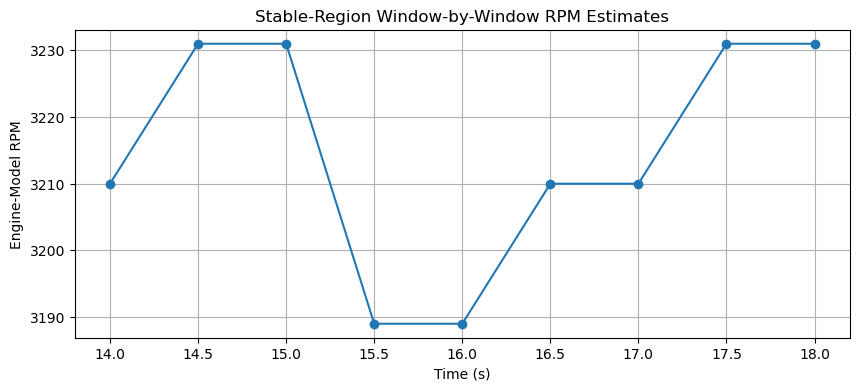

In [10]:
import matplotlib.pyplot as plt

times = [w["global_start_time_sec"] for w in good_window_results]
rpms = [w["rpm_engine_model"] for w in good_window_results]

plt.figure(figsize=(10, 4))
plt.plot(times, rpms, marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Engine-Model RPM")
plt.title("Stable-Region Window-by-Window RPM Estimates")
plt.grid(True)
plt.show()

5th Iteration of code to find RPM without known engine specs, attempting to estimate RPM based off frequency using the literature we reviewed earlier

In [11]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# ---------------------------
# Load + normalize audio
# ---------------------------
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


# ---------------------------
# Select best steady-state segment
# ---------------------------
def select_steady_state_segment(x, sr, choose_sec=8.0):
    frame_len = int(1.0 * sr)
    hop_len = int(0.25 * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x, 0.0

    starts = np.arange(0, len(x) - frame_len, hop_len)

    rms_vals = []
    centroid_vals = []

    for s in starts:
        frame = x[s:s + frame_len]
        rms = np.sqrt(np.mean(frame**2))

        freqs, psd = sig.welch(frame, fs=sr, nperseg=min(4096, len(frame)))
        centroid = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0.0

        rms_vals.append(rms)
        centroid_vals.append(centroid)

    rms_vals = np.array(rms_vals)
    centroid_vals = np.array(centroid_vals)

    best_score = np.inf
    best_start = 0
    window = int(choose_sec / 0.25)

    for i in range(len(starts) - window):
        score = np.std(rms_vals[i:i+window]) + 0.001 * np.std(centroid_vals[i:i+window])
        if score < best_score:
            best_score = score
            best_start = starts[i]

    return x[best_start:best_start + choose_len], best_start / sr


# ---------------------------
# Bandpass filter
# ---------------------------
def bandpass_filter(x, sr, low=20, high=1200):
    sos = sig.butter(6, [low, high], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


# ---------------------------
# Light STFT spectral subtraction
# Inspired by magnitude spectral subtraction idea
# ---------------------------
def spectral_subtraction_denoise(x, sr, nperseg=4096, noverlap=3072, strength=0.8):
    f, t, Zxx = sig.stft(x, fs=sr, window="hann", nperseg=nperseg, noverlap=noverlap)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)

    # Robust noise floor estimate per frequency bin
    noise_floor = np.median(mag, axis=1, keepdims=True)

    mag_clean = np.maximum(mag - strength * noise_floor, 0.0)
    Z_clean = mag_clean * np.exp(1j * phase)

    _, x_clean = sig.istft(Z_clean, fs=sr, window="hann", nperseg=nperseg, noverlap=noverlap)
    return x_clean[:len(x)]


# ---------------------------
# Welch PSD
# ---------------------------
def welch_spectrum(x, sr, nperseg=16384):
    nperseg = min(nperseg, len(x))
    if nperseg < 1024:
        nperseg = len(x)

    f, pxx = sig.welch(
        x,
        fs=sr,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        scaling="spectrum"
    )
    return f, pxx


# ---------------------------
# Cepstrum check
# ---------------------------
def cepstrum_check(x, sr, fmin=10, fmax=150):
    n = min(len(x), 65536)
    if n < 2048:
        return None

    xw = x[:n] * np.hanning(n)
    spec = np.abs(np.fft.rfft(xw)) + 1e-12
    ceps = np.fft.irfft(np.log(spec))
    quef = np.arange(len(ceps)) / sr

    mask = (quef > 1 / fmax) & (quef < 1 / fmin)
    if np.any(mask):
        q_peak = quef[mask][np.argmax(ceps[mask])]
        return 1.0 / q_peak

    return None


# ---------------------------
# Harmonic-sum detector
# ---------------------------
def harmonic_sum_score(freqs, power, fmin=10, fmax=150, max_harmonics=8):
    candidates = np.arange(fmin, fmax, 0.1)
    scores = np.zeros_like(candidates)

    for i, f0 in enumerate(candidates):
        score = 0.0
        weight_sum = 0.0

        for k in range(1, max_harmonics + 1):
            fk = k * f0
            if fk > freqs[-1]:
                break

            idx = np.argmin(np.abs(freqs - fk))
            w = 1.0 / k
            score += w * power[idx]
            weight_sum += w

        if weight_sum > 0:
            scores[i] = score / weight_sum

    best_idx = np.argmax(scores)
    return float(candidates[best_idx]), scores, candidates


# ---------------------------
# THD-like concentration metric
# ---------------------------
def thd_like_ratio(freqs, power, f0, max_harmonics=8, tol_hz=1.5):
    total_energy = np.sum(power)
    if total_energy <= 0:
        return 0.0, 0

    harm_energy = 0.0
    matched = 0

    for k in range(2, max_harmonics + 1):
        fk = k * f0
        if fk > freqs[-1]:
            break
        idx = np.argmin(np.abs(freqs - fk))
        if abs(freqs[idx] - fk) <= tol_hz:
            harm_energy += power[idx]
            matched += 1

    return float(harm_energy / total_energy), matched


# ---------------------------
# Dominant-band SNR-like metric
# ---------------------------
def snr_like_metric(freqs, power, f0, max_harmonics=8, tol_hz=2.0):
    total = np.sum(power)
    if total <= 0:
        return 0.0

    band_energy = 0.0
    for k in range(1, max_harmonics + 1):
        fk = k * f0
        if fk > freqs[-1]:
            break
        mask = np.abs(freqs - fk) <= tol_hz
        band_energy += np.sum(power[mask])

    residual = max(total - band_energy, 1e-12)
    return float(10 * np.log10((band_energy + 1e-12) / residual))


# ---------------------------
# Analyze one short window
# ---------------------------
def analyze_window(window_x, sr, fmin=10, fmax=150):
    x_bp = bandpass_filter(window_x, sr, low=20, high=1200)
    x_dn = spectral_subtraction_denoise(x_bp, sr, nperseg=4096, noverlap=3072, strength=0.8)

    freqs, pxx = welch_spectrum(x_dn, sr, nperseg=16384)

    mask = (freqs >= fmin) & (freqs <= 300)
    freqs = freqs[mask]
    pxx = pxx[mask]

    if len(freqs) < 10 or np.max(pxx) <= 0:
        return None

    f_detected, scores, candidates = harmonic_sum_score(freqs, pxx, fmin=fmin, fmax=fmax, max_harmonics=8)
    f_cep = cepstrum_check(x_dn, sr, fmin=fmin, fmax=fmax)

    sorted_scores = np.sort(scores)
    second_best = sorted_scores[-2] if len(sorted_scores) > 1 else sorted_scores[-1]
    confidence_ratio = float(np.max(scores) / (second_best + 1e-12))

    thd_ratio, matched_harmonics = thd_like_ratio(freqs, pxx, f_detected, max_harmonics=8, tol_hz=1.5)
    snr_db = snr_like_metric(freqs, pxx, f_detected, max_harmonics=8, tol_hz=2.0)

    return {
        "detected_frequency_hz": float(f_detected),
        "cepstrum_hz": float(f_cep) if f_cep is not None else None,
        "confidence_ratio": float(confidence_ratio),
        "matched_harmonics": int(matched_harmonics + 1),  # include 1x line conceptually
        "thd_like_ratio": float(thd_ratio),
        "snr_like_db": float(snr_db)
    }


# ---------------------------
# EWMA smoothing
# ---------------------------
def ewma(x, alpha=0.35):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y


# ---------------------------
# Candidate RPM mapping for unknown engines
# ---------------------------
def candidate_engine_rpms_from_frequency(f_hz):
    # Common 4-stroke firing-frequency interpretations
    common_cylinders = [3, 4, 6, 8]
    out = {}
    for cyl in common_cylinders:
        out[f"4stroke_{cyl}cyl"] = round(120.0 * f_hz / cyl, 1)
    # Also provide direct 1x rotational interpretation
    out["direct_1x_rotation"] = round(60.0 * f_hz, 1)
    return out


# ---------------------------
# Main literature-backed estimator
# ---------------------------
def estimate_rpm_lit_guided(
    wav_path,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=150.0,
    ewma_alpha=0.35
):
    sr, x = load_wav_mono(wav_path)

    # 1) steady-state region first
    x_seg, seg_start_sec = select_steady_state_segment(x, sr, choose_sec=choose_sec)

    # 2) overlapping short windows inside stable segment
    win_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)

    if len(x_seg) < win_len:
        raise ValueError("Selected steady-state segment is shorter than the analysis window.")

    starts = np.arange(0, len(x_seg) - win_len + 1, hop_len)

    results = []
    for i, s in enumerate(starts):
        xw = x_seg[s:s + win_len]
        out = analyze_window(xw, sr, fmin=fmin, fmax=fmax)
        if out is not None:
            out["window_index"] = int(i)
            out["global_start_time_sec"] = float(seg_start_sec + s / sr)
            results.append(out)

    if len(results) == 0:
        raise ValueError("No usable windows were found.")

    raw_freqs = np.array([r["detected_frequency_hz"] for r in results], dtype=float)
    smoothed_freqs = ewma(raw_freqs, alpha=ewma_alpha)

    # Robustly keep windows near the smoothed center
    med = np.median(smoothed_freqs)
    mad = np.median(np.abs(smoothed_freqs - med))

    if mad < 1e-6:
        good_mask = np.ones(len(smoothed_freqs), dtype=bool)
    else:
        robust_z = 0.6745 * (smoothed_freqs - med) / mad
        good_mask = np.abs(robust_z) <= 2.5

    good_results = [results[i] for i in range(len(results)) if good_mask[i]]
    if len(good_results) == 0:
        good_results = results

    freq_vals = np.array([r["detected_frequency_hz"] for r in good_results], dtype=float)
    conf_vals = np.array([r["confidence_ratio"] for r in good_results], dtype=float)
    harm_vals = np.array([r["matched_harmonics"] for r in good_results], dtype=float)
    thd_vals = np.array([r["thd_like_ratio"] for r in good_results], dtype=float)
    snr_vals = np.array([r["snr_like_db"] for r in good_results], dtype=float)

    final_freq = float(np.median(freq_vals))
    freq_std = float(np.std(freq_vals))
    freq_iqr = float(np.percentile(freq_vals, 75) - np.percentile(freq_vals, 25))

    # confidence score
    stability_term = max(0.0, 1.0 - freq_std / max(final_freq, 1.0))
    harmonic_term = min(np.mean(harm_vals) / 6.0, 1.0)
    sharpness_term = min(np.mean(conf_vals) / 1.5, 1.0)
    snr_term = min(max((np.mean(snr_vals) + 10.0) / 20.0, 0.0), 1.0)

    confidence_score = 100.0 * (
        0.35 * stability_term +
        0.25 * harmonic_term +
        0.20 * sharpness_term +
        0.20 * snr_term
    )

    summary = {
        "selected_steady_state_start_sec": round(float(seg_start_sec), 2),
        "selected_steady_state_duration_sec": round(float(choose_sec), 2),
        "engine_related_periodic_frequency_hz": round(final_freq, 2),
        "frequency_std_hz": round(freq_std, 2),
        "frequency_iqr_hz": round(freq_iqr, 2),
        "confidence_score_0_to_100": round(float(confidence_score), 1),
        "average_matched_harmonics": round(float(np.mean(harm_vals)), 2),
        "average_thd_like_ratio": round(float(np.mean(thd_vals)), 4),
        "average_snr_like_db": round(float(np.mean(snr_vals)), 2),
        "usable_windows": int(len(results)),
        "good_windows_used": int(len(good_results)),
        "candidate_rpms_from_final_frequency": candidate_engine_rpms_from_frequency(final_freq),
        "window_frequencies_hz": [round(float(v), 2) for v in freq_vals]
    }

    return summary, results, good_results

In [12]:
summary, all_window_results, good_window_results = estimate_rpm_lit_guided(
    "ToyotaRav4_3000RPM.wav",
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=150.0,
    ewma_alpha=0.35
)

summary

{'selected_steady_state_start_sec': 13.0,
 'selected_steady_state_duration_sec': 8.0,
 'engine_related_periodic_frequency_hz': 106.3,
 'frequency_std_hz': 18.98,
 'frequency_iqr_hz': 41.0,
 'confidence_score_0_to_100': 55.4,
 'average_matched_harmonics': 2.62,
 'average_thd_like_ratio': 0.0254,
 'average_snr_like_db': -7.61,
 'usable_windows': 13,
 'good_windows_used': 13,
 'candidate_rpms_from_final_frequency': {'4stroke_3cyl': 4252.0,
  '4stroke_4cyl': 3189.0,
  '4stroke_6cyl': 2126.0,
  '4stroke_8cyl': 1594.5,
  'direct_1x_rotation': 6378.0},
 'window_frequencies_hz': [66.0,
  66.0,
  107.0,
  109.2,
  107.7,
  106.3,
  106.3,
  106.3,
  107.0,
  107.0,
  107.0,
  66.0,
  66.0]}

In [13]:
for w in good_window_results:
    print(
        f"Window {w['window_index']:2d} | "
        f"t = {w['global_start_time_sec']:.2f} s | "
        f"Freq = {w['detected_frequency_hz']:.2f} Hz | "
        f"Cep = {w['cepstrum_hz'] if w['cepstrum_hz'] is not None else 'None'} | "
        f"Harmonics = {w['matched_harmonics']} | "
        f"SNR-like = {w['snr_like_db']:.2f} dB"
    )

Window  0 | t = 13.00 s | Freq = 66.00 Hz | Cep = 11.72161172161172 | Harmonics = 4 | SNR-like = -7.44 dB
Window  1 | t = 13.50 s | Freq = 66.00 Hz | Cep = 11.715889675372225 | Harmonics = 4 | SNR-like = -6.44 dB
Window  2 | t = 14.00 s | Freq = 107.00 Hz | Cep = 11.715889675372225 | Harmonics = 2 | SNR-like = -9.13 dB
Window  3 | t = 14.50 s | Freq = 109.20 Hz | Cep = 11.72161172161172 | Harmonics = 2 | SNR-like = -9.23 dB
Window  4 | t = 15.00 s | Freq = 107.70 Hz | Cep = 15.625 | Harmonics = 2 | SNR-like = -9.63 dB
Window  5 | t = 15.50 s | Freq = 106.30 Hz | Cep = 15.625 | Harmonics = 2 | SNR-like = -9.40 dB
Window  6 | t = 16.00 s | Freq = 106.30 Hz | Cep = 11.72161172161172 | Harmonics = 2 | SNR-like = -9.09 dB
Window  7 | t = 16.50 s | Freq = 106.30 Hz | Cep = 11.715889675372225 | Harmonics = 2 | SNR-like = -8.96 dB
Window  8 | t = 17.00 s | Freq = 107.00 Hz | Cep = 11.72161172161172 | Harmonics = 2 | SNR-like = -6.84 dB
Window  9 | t = 17.50 s | Freq = 107.00 Hz | Cep = 23.4375

6th Iteration of code to find RPM without known engine specs, attempting to estimate RPM based off frequency using the literature we reviewed earlier by adding realisitc engine constraints and automatically pick the best RPM candidate, 

In [16]:
import numpy as np


def classify_rpm_band(rpm):
    if rpm < 500:
        return "very_low_or_non_engine"
    elif rpm < 900:
        return "low_idle"
    elif rpm < 1300:
        return "idle"
    elif rpm < 2200:
        return "low_operating"
    elif rpm < 3200:
        return "medium_operating"
    elif rpm < 4500:
        return "high_operating"
    else:
        return "very_high_or_unlikely"


def score_rpm_candidate(
    rpm,
    label,
    final_freq,
    avg_harmonics,
    confidence_score,
    avg_snr_like_db,
    cepstrum_values=None
):
    """
    Higher score = more plausible interpretation
    """

    score = 0.0

    # ---------------------------------
    # 1) Realistic RPM prior
    # ---------------------------------
    # General-purpose machinery / vehicle heuristic
    if 600 <= rpm <= 3500:
        score += 35
    elif 400 <= rpm <= 4500:
        score += 22
    elif 200 <= rpm <= 5500:
        score += 10
    else:
        score -= 20

    # Slight preference against extremely high direct interpretations
    if rpm > 5000:
        score -= 20

    # ---------------------------------
    # 2) Reward acoustic confidence
    # ---------------------------------
    score += 0.25 * confidence_score

    # ---------------------------------
    # 3) Reward harmonic support
    # ---------------------------------
    score += 4.0 * avg_harmonics

    # ---------------------------------
    # 4) Reward better SNR-like values
    # ---------------------------------
    score += max(min(avg_snr_like_db, 10), -10)

    # ---------------------------------
    # 5) Cepstrum support
    # ---------------------------------
    # If cepstrum suggests a rotational base, prefer candidates that
    # imply a plausible relation to that lower frequency.
    if cepstrum_values is not None and len(cepstrum_values) > 0:
        cep_med = float(np.median(cepstrum_values))

        # For direct rotation, compare freq directly to cepstrum
        if label == "direct_1x_rotation":
            rel_err = abs(final_freq - cep_med) / max(cep_med, 1e-9)
            if rel_err < 0.15:
                score += 15
            elif rel_err < 0.30:
                score += 8

        # For firing-frequency interpretations, compare possible implied rotation
        else:
            # infer rotation from rpm
            implied_rot_hz = rpm / 60.0
            rel_err = abs(implied_rot_hz - cep_med) / max(cep_med, 1e-9)
            if rel_err < 0.15:
                score += 20
            elif rel_err < 0.30:
                score += 10

    # ---------------------------------
    # 6) Interpretation-specific prior
    # ---------------------------------
    if "4stroke_4cyl" in label:
        score += 8
    elif "4stroke_6cyl" in label:
        score += 4
    elif "4stroke_3cyl" in label:
        score += 2
    elif "4stroke_8cyl" in label:
        score += 1

    return float(score)


def build_engine_signature(summary, good_window_results):
    """
    Create a compact acoustic signature for downstream categorization.
    """
    freq_vals = np.array([w["detected_frequency_hz"] for w in good_window_results], dtype=float)
    cep_vals = np.array(
        [w["cepstrum_hz"] for w in good_window_results if w["cepstrum_hz"] is not None],
        dtype=float
    )

    signature = {
        "engine_related_periodic_frequency_hz": round(float(summary["engine_related_periodic_frequency_hz"]), 2),
        "frequency_std_hz": round(float(summary["frequency_std_hz"]), 2),
        "confidence_score_0_to_100": round(float(summary["confidence_score_0_to_100"]), 1),
        "average_matched_harmonics": round(float(summary["average_matched_harmonics"]), 2),
        "average_snr_like_db": round(float(summary["average_snr_like_db"]), 2),
        "median_cepstrum_hz": round(float(np.median(cep_vals)), 2) if len(cep_vals) > 0 else None,
        "frequency_cluster_count_estimate": int(len(np.unique(np.round(freq_vals, 1)))),
    }

    return signature


def rank_rpm_candidates(summary, good_window_results):
    final_freq = float(summary["engine_related_periodic_frequency_hz"])
    confidence_score = float(summary["confidence_score_0_to_100"])
    avg_harmonics = float(summary["average_matched_harmonics"])
    avg_snr_like_db = float(summary["average_snr_like_db"])
    candidates = summary["candidate_rpms_from_final_frequency"]

    cep_vals = [w["cepstrum_hz"] for w in good_window_results if w["cepstrum_hz"] is not None]

    ranked = []
    for label, rpm in candidates.items():
        score = score_rpm_candidate(
            rpm=rpm,
            label=label,
            final_freq=final_freq,
            avg_harmonics=avg_harmonics,
            confidence_score=confidence_score,
            avg_snr_like_db=avg_snr_like_db,
            cepstrum_values=cep_vals
        )

        ranked.append({
            "candidate_label": label,
            "rpm": round(float(rpm), 1),
            "operating_band": classify_rpm_band(float(rpm)),
            "ranking_score": round(float(score), 2)
        })

    ranked = sorted(ranked, key=lambda x: x["ranking_score"], reverse=True)

    best = ranked[0]

    result = {
        "best_rpm_candidate": best,
        "ranked_candidates": ranked,
        "engine_signature": build_engine_signature(summary, good_window_results)
    }

    return result


def classify_engine_characteristics(best_rpm_result):
    """
    Lightweight project-friendly classification summary.
    This does NOT identify a specific Caterpillar model.
    It just creates useful buckets for later narrowing.
    """
    best = best_rpm_result["best_rpm_candidate"]
    sig = best_rpm_result["engine_signature"]

    rpm = best["rpm"]
    band = best["operating_band"]
    freq_std = sig["frequency_std_hz"]
    harm = sig["average_matched_harmonics"]
    conf = sig["confidence_score_0_to_100"]

    if conf >= 75:
        confidence_label = "high_confidence"
    elif conf >= 50:
        confidence_label = "moderate_confidence"
    else:
        confidence_label = "low_confidence"

    if freq_std < 5:
        steadiness = "highly_steady"
    elif freq_std < 15:
        steadiness = "moderately_steady"
    else:
        steadiness = "variable_or_multi-regime"

    if harm >= 4:
        harmonic_structure = "strong_harmonic_structure"
    elif harm >= 2:
        harmonic_structure = "moderate_harmonic_structure"
    else:
        harmonic_structure = "weak_harmonic_structure"

    return {
        "most_likely_rpm": rpm,
        "most_likely_interpretation": best["candidate_label"],
        "operating_band": band,
        "confidence_label": confidence_label,
        "steadiness_label": steadiness,
        "harmonic_structure_label": harmonic_structure
    }

In [17]:
ranked_result = rank_rpm_candidates(summary, good_window_results)
ranked_result

{'best_rpm_candidate': {'candidate_label': '4stroke_4cyl',
  'rpm': 3189.0,
  'operating_band': 'medium_operating',
  'ranking_score': 59.72},
 'ranked_candidates': [{'candidate_label': '4stroke_4cyl',
   'rpm': 3189.0,
   'operating_band': 'medium_operating',
   'ranking_score': 59.72},
  {'candidate_label': '4stroke_6cyl',
   'rpm': 2126.0,
   'operating_band': 'low_operating',
   'ranking_score': 55.72},
  {'candidate_label': '4stroke_8cyl',
   'rpm': 1594.5,
   'operating_band': 'low_operating',
   'ranking_score': 52.72},
  {'candidate_label': '4stroke_3cyl',
   'rpm': 4252.0,
   'operating_band': 'high_operating',
   'ranking_score': 40.72},
  {'candidate_label': 'direct_1x_rotation',
   'rpm': 6378.0,
   'operating_band': 'very_high_or_unlikely',
   'ranking_score': -23.28}],
 'engine_signature': {'engine_related_periodic_frequency_hz': 106.3,
  'frequency_std_hz': 18.98,
  'confidence_score_0_to_100': 55.4,
  'average_matched_harmonics': 2.62,
  'average_snr_like_db': -7.61,
  

In [18]:
final_classification = classify_engine_characteristics(ranked_result)
final_classification

{'most_likely_rpm': 3189.0,
 'most_likely_interpretation': '4stroke_4cyl',
 'operating_band': 'medium_operating',
 'confidence_label': 'moderate_confidence',
 'steadiness_label': 'variable_or_multi-regime',
 'harmonic_structure_label': 'moderate_harmonic_structure'}

In [19]:
print("=== BEST RPM CANDIDATE ===")
print(ranked_result["best_rpm_candidate"])

print("\n=== ALL RANKED CANDIDATES ===")
for c in ranked_result["ranked_candidates"]:
    print(c)

print("\n=== ENGINE SIGNATURE ===")
print(ranked_result["engine_signature"])

print("\n=== FINAL CLASSIFICATION ===")
print(final_classification)

=== BEST RPM CANDIDATE ===
{'candidate_label': '4stroke_4cyl', 'rpm': 3189.0, 'operating_band': 'medium_operating', 'ranking_score': 59.72}

=== ALL RANKED CANDIDATES ===
{'candidate_label': '4stroke_4cyl', 'rpm': 3189.0, 'operating_band': 'medium_operating', 'ranking_score': 59.72}
{'candidate_label': '4stroke_6cyl', 'rpm': 2126.0, 'operating_band': 'low_operating', 'ranking_score': 55.72}
{'candidate_label': '4stroke_8cyl', 'rpm': 1594.5, 'operating_band': 'low_operating', 'ranking_score': 52.72}
{'candidate_label': '4stroke_3cyl', 'rpm': 4252.0, 'operating_band': 'high_operating', 'ranking_score': 40.72}
{'candidate_label': 'direct_1x_rotation', 'rpm': 6378.0, 'operating_band': 'very_high_or_unlikely', 'ranking_score': -23.28}

=== ENGINE SIGNATURE ===
{'engine_related_periodic_frequency_hz': 106.3, 'frequency_std_hz': 18.98, 'confidence_score_0_to_100': 55.4, 'average_matched_harmonics': 2.62, 'average_snr_like_db': -7.61, 'median_cepstrum_hz': 11.72, 'frequency_cluster_count_estim

7th Iteration of RPM with all code combined into 1 cell.

In [20]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# =========================
# AUDIO PREP
# =========================
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


def select_steady_state_segment(x, sr, choose_sec=8.0):
    frame_len = int(1.0 * sr)
    hop_len = int(0.25 * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x, 0.0

    starts = np.arange(0, len(x) - frame_len, hop_len)

    rms_vals = []
    centroid_vals = []

    for s in starts:
        frame = x[s:s + frame_len]
        rms = np.sqrt(np.mean(frame**2))

        freqs, psd = sig.welch(frame, fs=sr, nperseg=min(4096, len(frame)))
        centroid = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0.0

        rms_vals.append(rms)
        centroid_vals.append(centroid)

    rms_vals = np.array(rms_vals)
    centroid_vals = np.array(centroid_vals)

    best_score = np.inf
    best_start = 0
    window = int(choose_sec / 0.25)

    for i in range(len(starts) - window):
        score = np.std(rms_vals[i:i+window]) + 0.001 * np.std(centroid_vals[i:i+window])
        if score < best_score:
            best_score = score
            best_start = starts[i]

    return x[best_start:best_start + choose_len], best_start / sr


def bandpass_filter(x, sr, low=20, high=1200):
    sos = sig.butter(6, [low, high], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


def spectral_subtraction_denoise(x, sr, nperseg=4096, noverlap=3072, strength=0.8):
    f, t, Zxx = sig.stft(x, fs=sr, window="hann", nperseg=nperseg, noverlap=noverlap)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)

    noise_floor = np.median(mag, axis=1, keepdims=True)
    mag_clean = np.maximum(mag - strength * noise_floor, 0.0)
    Z_clean = mag_clean * np.exp(1j * phase)

    _, x_clean = sig.istft(Z_clean, fs=sr, window="hann", nperseg=nperseg, noverlap=noverlap)
    return x_clean[:len(x)]


def welch_spectrum(x, sr, nperseg=16384):
    nperseg = min(nperseg, len(x))
    if nperseg < 1024:
        nperseg = len(x)

    f, pxx = sig.welch(
        x,
        fs=sr,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        scaling="spectrum"
    )
    return f, pxx


def cepstrum_check(x, sr, fmin=10, fmax=150):
    n = min(len(x), 65536)
    if n < 2048:
        return None

    xw = x[:n] * np.hanning(n)
    spec = np.abs(np.fft.rfft(xw)) + 1e-12
    ceps = np.fft.irfft(np.log(spec))
    quef = np.arange(len(ceps)) / sr

    mask = (quef > 1 / fmax) & (quef < 1 / fmin)
    if np.any(mask):
        q_peak = quef[mask][np.argmax(ceps[mask])]
        return 1.0 / q_peak

    return None


# =========================
# FEATURE EXTRACTION
# =========================
def harmonic_sum_score(freqs, power, fmin=10, fmax=150, max_harmonics=8):
    candidates = np.arange(fmin, fmax, 0.1)
    scores = np.zeros_like(candidates)

    for i, f0 in enumerate(candidates):
        score = 0.0
        weight_sum = 0.0

        for k in range(1, max_harmonics + 1):
            fk = k * f0
            if fk > freqs[-1]:
                break

            idx = np.argmin(np.abs(freqs - fk))
            w = 1.0 / k
            score += w * power[idx]
            weight_sum += w

        if weight_sum > 0:
            scores[i] = score / weight_sum

    best_idx = np.argmax(scores)
    return float(candidates[best_idx]), scores, candidates


def thd_like_ratio(freqs, power, f0, max_harmonics=8, tol_hz=1.5):
    total_energy = np.sum(power)
    if total_energy <= 0:
        return 0.0, 0

    harm_energy = 0.0
    matched = 0

    for k in range(2, max_harmonics + 1):
        fk = k * f0
        if fk > freqs[-1]:
            break
        idx = np.argmin(np.abs(freqs - fk))
        if abs(freqs[idx] - fk) <= tol_hz:
            harm_energy += power[idx]
            matched += 1

    return float(harm_energy / total_energy), matched


def snr_like_metric(freqs, power, f0, max_harmonics=8, tol_hz=2.0):
    total = np.sum(power)
    if total <= 0:
        return 0.0

    band_energy = 0.0
    for k in range(1, max_harmonics + 1):
        fk = k * f0
        if fk > freqs[-1]:
            break
        mask = np.abs(freqs - fk) <= tol_hz
        band_energy += np.sum(power[mask])

    residual = max(total - band_energy, 1e-12)
    return float(10 * np.log10((band_energy + 1e-12) / residual))


def analyze_window(window_x, sr, fmin=10, fmax=150):
    x_bp = bandpass_filter(window_x, sr, low=20, high=1200)
    x_dn = spectral_subtraction_denoise(x_bp, sr, nperseg=4096, noverlap=3072, strength=0.8)

    freqs, pxx = welch_spectrum(x_dn, sr, nperseg=16384)

    mask = (freqs >= fmin) & (freqs <= 300)
    freqs = freqs[mask]
    pxx = pxx[mask]

    if len(freqs) < 10 or np.max(pxx) <= 0:
        return None

    f_detected, scores, candidates = harmonic_sum_score(freqs, pxx, fmin=fmin, fmax=fmax, max_harmonics=8)
    f_cep = cepstrum_check(x_dn, sr, fmin=fmin, fmax=fmax)

    sorted_scores = np.sort(scores)
    second_best = sorted_scores[-2] if len(sorted_scores) > 1 else sorted_scores[-1]
    confidence_ratio = float(np.max(scores) / (second_best + 1e-12))

    thd_ratio, matched_harmonics = thd_like_ratio(freqs, pxx, f_detected, max_harmonics=8, tol_hz=1.5)
    snr_db = snr_like_metric(freqs, pxx, f_detected, max_harmonics=8, tol_hz=2.0)

    return {
        "detected_frequency_hz": float(f_detected),
        "cepstrum_hz": float(f_cep) if f_cep is not None else None,
        "confidence_ratio": float(confidence_ratio),
        "matched_harmonics": int(matched_harmonics + 1),
        "thd_like_ratio": float(thd_ratio),
        "snr_like_db": float(snr_db)
    }


def ewma(x, alpha=0.35):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y


# =========================
# RPM INTERPRETATION
# =========================
def candidate_engine_rpms_from_frequency(f_hz):
    common_cylinders = [3, 4, 6, 8]
    out = {}
    for cyl in common_cylinders:
        out[f"4stroke_{cyl}cyl"] = round(120.0 * f_hz / cyl, 1)
    out["direct_1x_rotation"] = round(60.0 * f_hz, 1)
    return out


def estimate_rpm_lit_guided(
    wav_path,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=150.0,
    ewma_alpha=0.35
):
    sr, x = load_wav_mono(wav_path)

    x_seg, seg_start_sec = select_steady_state_segment(x, sr, choose_sec=choose_sec)

    win_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)

    if len(x_seg) < win_len:
        raise ValueError("Selected steady-state segment is shorter than the analysis window.")

    starts = np.arange(0, len(x_seg) - win_len + 1, hop_len)

    results = []
    for i, s in enumerate(starts):
        xw = x_seg[s:s + win_len]
        out = analyze_window(xw, sr, fmin=fmin, fmax=fmax)
        if out is not None:
            out["window_index"] = int(i)
            out["global_start_time_sec"] = float(seg_start_sec + s / sr)
            results.append(out)

    if len(results) == 0:
        raise ValueError("No usable windows were found.")

    raw_freqs = np.array([r["detected_frequency_hz"] for r in results], dtype=float)
    smoothed_freqs = ewma(raw_freqs, alpha=ewma_alpha)

    med = np.median(smoothed_freqs)
    mad = np.median(np.abs(smoothed_freqs - med))

    if mad < 1e-6:
        good_mask = np.ones(len(smoothed_freqs), dtype=bool)
    else:
        robust_z = 0.6745 * (smoothed_freqs - med) / mad
        good_mask = np.abs(robust_z) <= 2.5

    good_results = [results[i] for i in range(len(results)) if good_mask[i]]
    if len(good_results) == 0:
        good_results = results

    freq_vals = np.array([r["detected_frequency_hz"] for r in good_results], dtype=float)
    conf_vals = np.array([r["confidence_ratio"] for r in good_results], dtype=float)
    harm_vals = np.array([r["matched_harmonics"] for r in good_results], dtype=float)
    thd_vals = np.array([r["thd_like_ratio"] for r in good_results], dtype=float)
    snr_vals = np.array([r["snr_like_db"] for r in good_results], dtype=float)

    final_freq = float(np.median(freq_vals))
    freq_std = float(np.std(freq_vals))
    freq_iqr = float(np.percentile(freq_vals, 75) - np.percentile(freq_vals, 25))

    stability_term = max(0.0, 1.0 - freq_std / max(final_freq, 1.0))
    harmonic_term = min(np.mean(harm_vals) / 6.0, 1.0)
    sharpness_term = min(np.mean(conf_vals) / 1.5, 1.0)
    snr_term = min(max((np.mean(snr_vals) + 10.0) / 20.0, 0.0), 1.0)

    confidence_score = 100.0 * (
        0.35 * stability_term +
        0.25 * harmonic_term +
        0.20 * sharpness_term +
        0.20 * snr_term
    )

    summary = {
        "selected_steady_state_start_sec": round(float(seg_start_sec), 2),
        "selected_steady_state_duration_sec": round(float(choose_sec), 2),
        "engine_related_periodic_frequency_hz": round(final_freq, 2),
        "frequency_std_hz": round(freq_std, 2),
        "frequency_iqr_hz": round(freq_iqr, 2),
        "confidence_score_0_to_100": round(float(confidence_score), 1),
        "average_matched_harmonics": round(float(np.mean(harm_vals)), 2),
        "average_thd_like_ratio": round(float(np.mean(thd_vals)), 4),
        "average_snr_like_db": round(float(np.mean(snr_vals)), 2),
        "usable_windows": int(len(results)),
        "good_windows_used": int(len(good_results)),
        "candidate_rpms_from_final_frequency": candidate_engine_rpms_from_frequency(final_freq),
        "window_frequencies_hz": [round(float(v), 2) for v in freq_vals]
    }

    return summary, results, good_results


# =========================
# RANKING + CLASSIFICATION
# =========================
def classify_rpm_band(rpm):
    if rpm < 500:
        return "very_low_or_non_engine"
    elif rpm < 900:
        return "low_idle"
    elif rpm < 1300:
        return "idle"
    elif rpm < 2200:
        return "low_operating"
    elif rpm < 3200:
        return "medium_operating"
    elif rpm < 4500:
        return "high_operating"
    else:
        return "very_high_or_unlikely"


def score_rpm_candidate(
    rpm,
    label,
    final_freq,
    avg_harmonics,
    confidence_score,
    avg_snr_like_db,
    cepstrum_values=None
):
    score = 0.0

    if 600 <= rpm <= 3500:
        score += 35
    elif 400 <= rpm <= 4500:
        score += 22
    elif 200 <= rpm <= 5500:
        score += 10
    else:
        score -= 20

    if rpm > 5000:
        score -= 20

    score += 0.25 * confidence_score
    score += 4.0 * avg_harmonics
    score += max(min(avg_snr_like_db, 10), -10)

    if cepstrum_values is not None and len(cepstrum_values) > 0:
        cep_med = float(np.median(cepstrum_values))

        if label == "direct_1x_rotation":
            rel_err = abs(final_freq - cep_med) / max(cep_med, 1e-9)
            if rel_err < 0.15:
                score += 15
            elif rel_err < 0.30:
                score += 8
        else:
            implied_rot_hz = rpm / 60.0
            rel_err = abs(implied_rot_hz - cep_med) / max(cep_med, 1e-9)
            if rel_err < 0.15:
                score += 20
            elif rel_err < 0.30:
                score += 10

    if "4stroke_4cyl" in label:
        score += 8
    elif "4stroke_6cyl" in label:
        score += 4
    elif "4stroke_3cyl" in label:
        score += 2
    elif "4stroke_8cyl" in label:
        score += 1

    return float(score)


def build_engine_signature(summary, good_window_results):
    freq_vals = np.array([w["detected_frequency_hz"] for w in good_window_results], dtype=float)
    cep_vals = np.array(
        [w["cepstrum_hz"] for w in good_window_results if w["cepstrum_hz"] is not None],
        dtype=float
    )

    signature = {
        "engine_related_periodic_frequency_hz": round(float(summary["engine_related_periodic_frequency_hz"]), 2),
        "frequency_std_hz": round(float(summary["frequency_std_hz"]), 2),
        "confidence_score_0_to_100": round(float(summary["confidence_score_0_to_100"]), 1),
        "average_matched_harmonics": round(float(summary["average_matched_harmonics"]), 2),
        "average_snr_like_db": round(float(summary["average_snr_like_db"]), 2),
        "median_cepstrum_hz": round(float(np.median(cep_vals)), 2) if len(cep_vals) > 0 else None,
        "frequency_cluster_count_estimate": int(len(np.unique(np.round(freq_vals, 1)))),
    }

    return signature


def rank_rpm_candidates(summary, good_window_results):
    final_freq = float(summary["engine_related_periodic_frequency_hz"])
    confidence_score = float(summary["confidence_score_0_to_100"])
    avg_harmonics = float(summary["average_matched_harmonics"])
    avg_snr_like_db = float(summary["average_snr_like_db"])
    candidates = summary["candidate_rpms_from_final_frequency"]

    cep_vals = [w["cepstrum_hz"] for w in good_window_results if w["cepstrum_hz"] is not None]

    ranked = []
    for label, rpm in candidates.items():
        score = score_rpm_candidate(
            rpm=rpm,
            label=label,
            final_freq=final_freq,
            avg_harmonics=avg_harmonics,
            confidence_score=confidence_score,
            avg_snr_like_db=avg_snr_like_db,
            cepstrum_values=cep_vals
        )

        ranked.append({
            "candidate_label": label,
            "rpm": round(float(rpm), 1),
            "operating_band": classify_rpm_band(float(rpm)),
            "ranking_score": round(float(score), 2)
        })

    ranked = sorted(ranked, key=lambda x: x["ranking_score"], reverse=True)

    return {
        "best_rpm_candidate": ranked[0],
        "ranked_candidates": ranked,
        "engine_signature": build_engine_signature(summary, good_window_results)
    }


def classify_engine_characteristics(best_rpm_result):
    best = best_rpm_result["best_rpm_candidate"]
    sig = best_rpm_result["engine_signature"]

    rpm = best["rpm"]
    band = best["operating_band"]
    freq_std = sig["frequency_std_hz"]
    harm = sig["average_matched_harmonics"]
    conf = sig["confidence_score_0_to_100"]

    if conf >= 75:
        confidence_label = "high_confidence"
    elif conf >= 50:
        confidence_label = "moderate_confidence"
    else:
        confidence_label = "low_confidence"

    if freq_std < 5:
        steadiness = "highly_steady"
    elif freq_std < 15:
        steadiness = "moderately_steady"
    else:
        steadiness = "variable_or_multi-regime"

    if harm >= 4:
        harmonic_structure = "strong_harmonic_structure"
    elif harm >= 2:
        harmonic_structure = "moderate_harmonic_structure"
    else:
        harmonic_structure = "weak_harmonic_structure"

    return {
        "most_likely_rpm": rpm,
        "most_likely_interpretation": best["candidate_label"],
        "operating_band": band,
        "confidence_label": confidence_label,
        "steadiness_label": steadiness,
        "harmonic_structure_label": harmonic_structure
    }

In [21]:
wav_path = "ToyotaRav4_3000RPM.wav"

summary, all_window_results, good_window_results = estimate_rpm_lit_guided(
    wav_path,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=150.0,
    ewma_alpha=0.35
)

ranked_result = rank_rpm_candidates(summary, good_window_results)
final_classification = classify_engine_characteristics(ranked_result)

print("=== SUMMARY ===")
print(summary)

print("\n=== GOOD WINDOW RESULTS ===")
for w in good_window_results:
    print(
        f"Window {w['window_index']:2d} | "
        f"t = {w['global_start_time_sec']:.2f} s | "
        f"Freq = {w['detected_frequency_hz']:.2f} Hz | "
        f"Cep = {w['cepstrum_hz'] if w['cepstrum_hz'] is not None else 'None'} | "
        f"Harmonics = {w['matched_harmonics']} | "
        f"SNR-like = {w['snr_like_db']:.2f} dB"
    )

print("\n=== BEST RPM CANDIDATE ===")
print(ranked_result["best_rpm_candidate"])

print("\n=== ALL RANKED CANDIDATES ===")
for c in ranked_result["ranked_candidates"]:
    print(c)

print("\n=== ENGINE SIGNATURE ===")
print(ranked_result["engine_signature"])

print("\n=== FINAL CLASSIFICATION ===")
print(final_classification)

=== SUMMARY ===
{'selected_steady_state_start_sec': 13.0, 'selected_steady_state_duration_sec': 8.0, 'engine_related_periodic_frequency_hz': 106.3, 'frequency_std_hz': 18.98, 'frequency_iqr_hz': 41.0, 'confidence_score_0_to_100': 55.4, 'average_matched_harmonics': 2.62, 'average_thd_like_ratio': 0.0254, 'average_snr_like_db': -7.61, 'usable_windows': 13, 'good_windows_used': 13, 'candidate_rpms_from_final_frequency': {'4stroke_3cyl': 4252.0, '4stroke_4cyl': 3189.0, '4stroke_6cyl': 2126.0, '4stroke_8cyl': 1594.5, 'direct_1x_rotation': 6378.0}, 'window_frequencies_hz': [66.0, 66.0, 107.0, 109.2, 107.7, 106.3, 106.3, 106.3, 107.0, 107.0, 107.0, 66.0, 66.0]}

=== GOOD WINDOW RESULTS ===
Window  0 | t = 13.00 s | Freq = 66.00 Hz | Cep = 11.72161172161172 | Harmonics = 4 | SNR-like = -7.44 dB
Window  1 | t = 13.50 s | Freq = 66.00 Hz | Cep = 11.715889675372225 | Harmonics = 4 | SNR-like = -6.44 dB
Window  2 | t = 14.00 s | Freq = 107.00 Hz | Cep = 11.715889675372225 | Harmonics = 2 | SNR-lik

In [22]:
wav_path = "BMW_4000_RPM.wav"

summary, all_window_results, good_window_results = estimate_rpm_lit_guided(
    wav_path,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=150.0,
    ewma_alpha=0.35
)

ranked_result = rank_rpm_candidates(summary, good_window_results)
final_classification = classify_engine_characteristics(ranked_result)

print("=== SUMMARY ===")
print(summary)

print("\n=== GOOD WINDOW RESULTS ===")
for w in good_window_results:
    print(
        f"Window {w['window_index']:2d} | "
        f"t = {w['global_start_time_sec']:.2f} s | "
        f"Freq = {w['detected_frequency_hz']:.2f} Hz | "
        f"Cep = {w['cepstrum_hz'] if w['cepstrum_hz'] is not None else 'None'} | "
        f"Harmonics = {w['matched_harmonics']} | "
        f"SNR-like = {w['snr_like_db']:.2f} dB"
    )

print("\n=== BEST RPM CANDIDATE ===")
print(ranked_result["best_rpm_candidate"])

print("\n=== ALL RANKED CANDIDATES ===")
for c in ranked_result["ranked_candidates"]:
    print(c)

print("\n=== ENGINE SIGNATURE ===")
print(ranked_result["engine_signature"])

print("\n=== FINAL CLASSIFICATION ===")
print(final_classification)

=== SUMMARY ===
{'selected_steady_state_start_sec': 7.75, 'selected_steady_state_duration_sec': 8.0, 'engine_related_periodic_frequency_hz': 122.5, 'frequency_std_hz': 1.46, 'frequency_iqr_hz': 2.7, 'confidence_score_0_to_100': 62.7, 'average_matched_harmonics': 2.0, 'average_thd_like_ratio': 0.1064, 'average_snr_like_db': -3.56, 'usable_windows': 13, 'good_windows_used': 13, 'candidate_rpms_from_final_frequency': {'4stroke_3cyl': 4900.0, '4stroke_4cyl': 3675.0, '4stroke_6cyl': 2450.0, '4stroke_8cyl': 1837.5, 'direct_1x_rotation': 7350.0}, 'window_frequencies_hz': [125.2, 125.2, 125.2, 125.2, 125.2, 125.2, 121.8, 121.8, 122.5, 122.5, 122.5, 122.5, 122.5]}

=== GOOD WINDOW RESULTS ===
Window  0 | t = 7.75 s | Freq = 125.20 Hz | Cep = 10.76397363924823 | Harmonics = 2 | SNR-like = -5.12 dB
Window  1 | t = 8.25 s | Freq = 125.20 Hz | Cep = 10.76397363924823 | Harmonics = 2 | SNR-like = -5.80 dB
Window  2 | t = 8.75 s | Freq = 125.20 Hz | Cep = 43.06640625 | Harmonics = 2 | SNR-like = -3.8

In [31]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# =========================
# Load + normalize audio
# =========================
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


# =========================
# Select a steady-state segment
# =========================
def select_steady_state_segment(x, sr, choose_sec=8.0):
    frame_len = int(1.0 * sr)
    hop_len = int(0.25 * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x, 0.0

    rms_vals = []
    starts = []

    for start in range(0, len(x) - frame_len + 1, hop_len):
        frame = x[start:start + frame_len]
        rms = np.sqrt(np.mean(frame**2))
        rms_vals.append(rms)
        starts.append(start)

    rms_vals = np.array(rms_vals)
    starts = np.array(starts)

    if len(rms_vals) == 0:
        return x[:choose_len], 0.0

    best_score = None
    best_start = 0

    choose_frames = max(1, int((choose_sec * sr - frame_len) / hop_len) + 1)

    for i in range(0, len(rms_vals) - choose_frames + 1):
        block = rms_vals[i:i + choose_frames]
        score = np.std(block) / (np.mean(block) + 1e-12)
        if best_score is None or score < best_score:
            best_score = score
            best_start = starts[i]

    best_end = min(best_start + choose_len, len(x))
    return x[best_start:best_end], best_start / sr


# =========================
# FFT peak detection
# =========================
def dominant_frequency_fft(x, sr, fmin=10.0, fmax=500.0):
    n = len(x)
    if n < 4:
        return None, None, None

    window = np.hanning(n)
    xw = x * window

    freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    mag = np.abs(np.fft.rfft(xw))

    valid = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(valid):
        return None, None, None

    freqs_v = freqs[valid]
    mag_v = mag[valid]

    peak_idx = np.argmax(mag_v)
    peak_freq = freqs_v[peak_idx]
    peak_mag = mag_v[peak_idx]

    return float(peak_freq), freqs_v, mag_v


# =========================
# Cepstrum estimate
# =========================
def cepstrum_fundamental(x, sr, fmin=10.0, fmax=500.0):
    n = len(x)
    if n < 4:
        return None

    xw = x * np.hanning(n)
    spectrum = np.fft.rfft(xw)
    log_mag = np.log(np.abs(spectrum) + 1e-12)
    cep = np.fft.irfft(log_mag)

    qmin = int(sr / fmax)
    qmax = int(sr / fmin)

    if qmax <= qmin or qmax >= len(cep):
        return None

    q_idx = np.argmax(cep[qmin:qmax]) + qmin
    if q_idx <= 0:
        return None

    return float(sr / q_idx)


# =========================
# Harmonic matching
# =========================
def harmonic_match_count(freq0, freqs, mag, max_harm=8, tol_pct=0.06):
    if freq0 is None or freqs is None or mag is None:
        return 0

    count = 0
    for h in range(2, max_harm + 1):
        target = h * freq0
        if target > freqs[-1]:
            break

        tol = tol_pct * target
        idx = np.where(np.abs(freqs - target) <= tol)[0]
        if len(idx) > 0 and np.max(mag[idx]) > 0.15 * np.max(mag):
            count += 1

    return count


# =========================
# Simple SNR-like score
# =========================
def snr_like_db(peak_mag, mag):
    if peak_mag is None or mag is None or len(mag) < 5:
        return None

    baseline = np.median(mag) + 1e-12
    return float(20.0 * np.log10((peak_mag + 1e-12) / baseline))


# =========================
# Evaluate one window
# =========================
def evaluate_window(xw, sr, fmin=10.0, fmax=500.0):
    peak_freq, freqs_v, mag_v = dominant_frequency_fft(xw, sr, fmin=fmin, fmax=fmax)
    cep_freq = cepstrum_fundamental(xw, sr, fmin=fmin, fmax=fmax)

    if peak_freq is None:
        return None

    matched_harmonics = harmonic_match_count(peak_freq, freqs_v, mag_v, max_harm=8, tol_pct=0.06)
    snr_db = snr_like_db(np.max(mag_v), mag_v)

    return {
        "detected_frequency_hz": float(peak_freq),
        "cepstrum_hz": None if cep_freq is None else float(cep_freq),
        "matched_harmonics": int(matched_harmonics),
        "snr_like_db": None if snr_db is None else float(snr_db),
    }


# =========================
# Sliding-window engine frequency analysis
# =========================
def analyze_windows(
    x_segment,
    sr,
    segment_start_time_sec=0.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=500.0
):
    win_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)

    all_window_results = []

    if len(x_segment) < win_len:
        return all_window_results

    for i, start in enumerate(range(0, len(x_segment) - win_len + 1, hop_len)):
        xw = x_segment[start:start + win_len]
        result = evaluate_window(xw, sr, fmin=fmin, fmax=fmax)

        if result is None:
            continue

        result["window_index"] = i
        result["local_start_time_sec"] = start / sr
        result["global_start_time_sec"] = segment_start_time_sec + start / sr
        all_window_results.append(result)

    return all_window_results


# =========================
# Keep only good windows
# =========================
def filter_good_windows(all_window_results, min_harmonics=1, min_snr_db=-8.0):
    good = []
    for w in all_window_results:
        harm_ok = w["matched_harmonics"] >= min_harmonics
        snr_ok = (w["snr_like_db"] is not None) and (w["snr_like_db"] >= min_snr_db)
        if harm_ok and snr_ok:
            good.append(w)
    return good


# =========================
# RPM summary for all cylinder assumptions
# =========================
def summarize_rpm_by_cylinder(good_window_results, cylinder_options=(3, 4, 5, 6, 8), strokes=4):
    freqs = [w["detected_frequency_hz"] for w in good_window_results if w["detected_frequency_hz"] is not None]

    if not freqs:
        return None

    avg_freq = float(np.mean(freqs))
    max_freq = float(np.max(freqs))
    freq_std = float(np.std(freqs))

    summary = {
        "average_detected_frequency_hz": avg_freq,
        "max_detected_frequency_hz": max_freq,
        "frequency_std_hz": freq_std,
        "candidates": []
    }

    for cyl in cylinder_options:
        if strokes == 4:
            avg_rpm = 120.0 * avg_freq / cyl
            max_rpm = 120.0 * max_freq / cyl
        elif strokes == 2:
            avg_rpm = 60.0 * avg_freq / cyl
            max_rpm = 60.0 * max_freq / cyl
        else:
            continue

        summary["candidates"].append({
            "strokes": strokes,
            "cylinders": cyl,
            "avg_rpm": float(avg_rpm),
            "max_rpm": float(max_rpm)
        })

    return summary


# =========================
# Better ranking logic
# =========================
def rank_candidates_with_vehicle_bias(
    good_window_results,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    expected_rpm_range=(2500, 4500),
    preferred_cylinders=(4,)
):
    freqs = [w["detected_frequency_hz"] for w in good_window_results if w["detected_frequency_hz"] is not None]
    snrs = [w["snr_like_db"] for w in good_window_results if w["snr_like_db"] is not None]
    harms = [w["matched_harmonics"] for w in good_window_results if w["matched_harmonics"] is not None]

    if not freqs:
        return []

    avg_freq = float(np.mean(freqs))
    max_freq = float(np.max(freqs))
    freq_std = float(np.std(freqs))
    avg_snr = float(np.mean(snrs)) if snrs else -10.0
    avg_harm = float(np.mean(harms)) if harms else 0.0

    ranked = []

    for cyl in cylinder_options:
        if strokes == 4:
            avg_rpm = 120.0 * avg_freq / cyl
            max_rpm = 120.0 * max_freq / cyl
            candidate_label = f"4stroke_{cyl}cyl"
        elif strokes == 2:
            avg_rpm = 60.0 * avg_freq / cyl
            max_rpm = 60.0 * max_freq / cyl
            candidate_label = f"2stroke_{cyl}cyl"
        else:
            continue

        stability_score = max(0.0, 30.0 - 8.0 * freq_std)
        harmonic_score = min(avg_harm * 10.0, 25.0)
        snr_score = max(0.0, min(20.0, avg_snr + 20.0))

        lo, hi = expected_rpm_range
        if lo <= avg_rpm <= hi:
            rpm_range_score = 25.0
        else:
            dist = min(abs(avg_rpm - lo), abs(avg_rpm - hi))
            rpm_range_score = max(0.0, 25.0 - dist / 80.0)

        cylinder_prior = 15.0 if cyl in preferred_cylinders else 0.0

        total_score = stability_score + harmonic_score + snr_score + rpm_range_score + cylinder_prior

        ranked.append({
            "candidate_label": candidate_label,
            "cylinders": cyl,
            "avg_rpm": float(avg_rpm),
            "max_rpm": float(max_rpm),
            "ranking_score": float(total_score)
        })

    ranked.sort(key=lambda x: x["ranking_score"], reverse=True)
    return ranked


# =========================
# Main wrapper
# =========================
def estimate_rpm_from_wav(
    wav_path,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=500.0,
    min_harmonics=1,
    min_snr_db=-8.0,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    expected_rpm_range=(2500, 4500),
    preferred_cylinders=(4,)
):
    sr, x = load_wav_mono(wav_path)

    x_segment, selected_start_time_sec = select_steady_state_segment(
        x, sr, choose_sec=choose_sec
    )

    all_window_results = analyze_windows(
        x_segment,
        sr,
        segment_start_time_sec=selected_start_time_sec,
        window_sec=window_sec,
        hop_sec=hop_sec,
        fmin=fmin,
        fmax=fmax
    )

    good_window_results = filter_good_windows(
        all_window_results,
        min_harmonics=min_harmonics,
        min_snr_db=min_snr_db
    )

    rpm_summary = summarize_rpm_by_cylinder(
        good_window_results,
        cylinder_options=cylinder_options,
        strokes=strokes
    )

    ranked_candidates = rank_candidates_with_vehicle_bias(
        good_window_results,
        cylinder_options=cylinder_options,
        strokes=strokes,
        expected_rpm_range=expected_rpm_range,
        preferred_cylinders=preferred_cylinders
    )

    return {
        "sr": sr,
        "selected_start_time_sec": selected_start_time_sec,
        "all_window_results": all_window_results,
        "good_window_results": good_window_results,
        "rpm_summary": rpm_summary,
        "ranked_candidates": ranked_candidates
    }


# =========================
# Print output cleanly
# =========================
def print_engine_rpm_report(results):
    good_window_results = results["good_window_results"]
    rpm_summary = results["rpm_summary"]
    ranked_candidates = results["ranked_candidates"]

    print("=== SUMMARY ===")
    print(f"Selected steady-state start: {results['selected_start_time_sec']:.2f} s")
    print(f"Good windows used: {len(good_window_results)}")

    if rpm_summary is None:
        print("No valid frequency results found.")
        return

    print(f"Average detected frequency: {rpm_summary['average_detected_frequency_hz']:.2f} Hz")
    print(f"Max detected frequency: {rpm_summary['max_detected_frequency_hz']:.2f} Hz")
    print(f"Frequency std: {rpm_summary['frequency_std_hz']:.2f} Hz")
    print()

    print("=== GOOD WINDOW RESULTS ===")
    for w in good_window_results:
        print(
            f"Window {w['window_index']:2d} | "
            f"t = {w['global_start_time_sec']:.2f} s | "
            f"Freq = {w['detected_frequency_hz']:.2f} Hz | "
            f"Cep = {w['cepstrum_hz'] if w['cepstrum_hz'] is not None else 'None'} | "
            f"Harmonics = {w['matched_harmonics']} | "
            f"SNR-like = {w['snr_like_db']:.2f} dB"
        )

    print()
    print("=== RPM SUMMARY BY CYLINDER ASSUMPTION ===")
    for c in rpm_summary["candidates"]:
        print(
            f"{c['strokes']}-stroke, {c['cylinders']} cylinders -> "
            f"Average RPM: {c['avg_rpm']:.1f} | "
            f"Max RPM: {c['max_rpm']:.1f}"
        )

    print()
    print("=== RANKED CANDIDATES ===")
    for r in ranked_candidates:
        print(
            f"{r['candidate_label']} -> "
            f"Average RPM: {r['avg_rpm']:.1f} | "
            f"Max RPM: {r['max_rpm']:.1f} | "
            f"Score: {r['ranking_score']:.2f}"
        )

    if ranked_candidates:
        best = ranked_candidates[0]
        print()
        print("=== BEST CANDIDATE ===")
        print(
            f"{best['candidate_label']} | "
            f"Average RPM: {best['avg_rpm']:.1f} | "
            f"Max RPM: {best['max_rpm']:.1f} | "
            f"Score: {best['ranking_score']:.2f}"
        )

In [32]:
wav_file = "Test 2.wav"   # replace with your actual .wav filename

results = estimate_rpm_from_wav(
    wav_file,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=500.0,
    min_harmonics=1,
    min_snr_db=-8.0,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    expected_rpm_range=(3000, 4500),   # adjust if needed
    preferred_cylinders=(4,)           # BMW case
)

print_engine_rpm_report(results)

=== SUMMARY ===
Selected steady-state start: 18.50 s
Good windows used: 5
Average detected frequency: 98.30 Hz
Max detected frequency: 99.50 Hz
Frequency std: 0.81 Hz

=== GOOD WINDOW RESULTS ===
Window  0 | t = 18.50 s | Freq = 99.50 Hz | Cep = 370.5882352941176 | Harmonics = 1 | SNR-like = 38.99 dB
Window  1 | t = 19.00 s | Freq = 99.00 Hz | Cep = 306.25 | Harmonics = 1 | SNR-like = 39.59 dB
Window  2 | t = 19.50 s | Freq = 97.50 Hz | Cep = 306.25 | Harmonics = 1 | SNR-like = 41.15 dB
Window 11 | t = 24.00 s | Freq = 98.00 Hz | Cep = 253.44827586206895 | Harmonics = 1 | SNR-like = 43.87 dB
Window 12 | t = 24.50 s | Freq = 97.50 Hz | Cep = 24.35118718939812 | Harmonics = 1 | SNR-like = 44.91 dB

=== RPM SUMMARY BY CYLINDER ASSUMPTION ===
4-stroke, 3 cylinders -> Average RPM: 3932.0 | Max RPM: 3980.0
4-stroke, 4 cylinders -> Average RPM: 2949.0 | Max RPM: 2985.0
4-stroke, 5 cylinders -> Average RPM: 2359.2 | Max RPM: 2388.0
4-stroke, 6 cylinders -> Average RPM: 1966.0 | Max RPM: 1990.0

In [36]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile


# =========================
# Load + normalize audio
# =========================
def load_wav_mono(path):
    sr, x = wavfile.read(path)
    x = x.astype(float)

    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak

    return sr, x


# =========================
# Bandpass filter
# =========================
def bandpass_filter(x, sr, low=20.0, high=1200.0, order=6):
    nyq = sr / 2.0
    high = min(high, 0.95 * nyq)
    low = max(low, 1.0)

    if low >= high:
        return x

    sos = sig.butter(order, [low, high], btype="bandpass", fs=sr, output="sos")
    return sig.sosfiltfilt(sos, x)


# =========================
# Welch spectrum
# =========================
def welch_spectrum(x, sr):
    nperseg = min(32768, len(x))
    if nperseg < 256:
        return None, None
    f, pxx = sig.welch(x, fs=sr, nperseg=nperseg)
    return f, pxx


# =========================
# Harmonic-sum frequency estimate
# =========================
def harmonic_sum_score(freqs, power, fmin=10.0, fmax=150.0, step=0.1, max_harm=8):
    if freqs is None or power is None or len(freqs) == 0:
        return None, None

    candidates = np.arange(fmin, fmax, step)
    if len(candidates) == 0:
        return None, None

    scores = []

    for f0 in candidates:
        score = 0.0
        weight_sum = 0.0

        for k in range(1, max_harm + 1):
            fk = k * f0
            if fk > freqs[-1]:
                break

            idx = np.argmin(np.abs(freqs - fk))
            w = 1.0 / k
            score += w * power[idx]
            weight_sum += w

        scores.append(score / weight_sum if weight_sum > 0 else 0.0)

    scores = np.array(scores)
    best_idx = np.argmax(scores)

    return float(candidates[best_idx]), float(scores[best_idx])


# =========================
# FFT peak detection
# =========================
def dominant_frequency_fft(x, sr, fmin=10.0, fmax=500.0):
    n = len(x)
    if n < 4:
        return None, None, None

    window = np.hanning(n)
    xw = x * window

    freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    mag = np.abs(np.fft.rfft(xw))

    valid = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(valid):
        return None, None, None

    freqs_v = freqs[valid]
    mag_v = mag[valid]

    peak_idx = np.argmax(mag_v)
    peak_freq = freqs_v[peak_idx]

    return float(peak_freq), freqs_v, mag_v


# =========================
# Cepstrum estimate
# =========================
def cepstrum_fundamental(x, sr, fmin=10.0, fmax=500.0):
    n = len(x)
    if n < 4:
        return None

    xw = x * np.hanning(n)
    spectrum = np.fft.rfft(xw)
    log_mag = np.log(np.abs(spectrum) + 1e-12)
    cep = np.fft.irfft(log_mag)

    qmin = int(sr / fmax)
    qmax = int(sr / fmin)

    if qmax <= qmin or qmax >= len(cep):
        return None

    q_idx = np.argmax(cep[qmin:qmax]) + qmin
    if q_idx <= 0:
        return None

    return float(sr / q_idx)


# =========================
# Harmonic matching
# =========================
def harmonic_match_count(freq0, freqs, mag, max_harm=8, tol_pct=0.06):
    if freq0 is None or freqs is None or mag is None:
        return 0

    count = 0
    for h in range(2, max_harm + 1):
        target = h * freq0
        if target > freqs[-1]:
            break

        tol = tol_pct * target
        idx = np.where(np.abs(freqs - target) <= tol)[0]
        if len(idx) > 0 and np.max(mag[idx]) > 0.15 * np.max(mag):
            count += 1

    return count


# =========================
# Simple SNR-like score
# =========================
def snr_like_db(peak_mag, mag):
    if peak_mag is None or mag is None or len(mag) < 5:
        return None

    baseline = np.median(mag) + 1e-12
    return float(20.0 * np.log10((peak_mag + 1e-12) / baseline))


# =========================
# Choose best engine frequency
# =========================
def choose_engine_frequency(f_fft, f_harm, f_cep):
    candidates = []

    if f_fft is not None:
        candidates.append(("fft", f_fft))
    if f_harm is not None:
        candidates.append(("harmonic_sum", f_harm))
    if f_cep is not None:
        candidates.append(("cepstrum", f_cep))

    if not candidates:
        return None, "none"

    if f_harm is not None and f_cep is not None:
        if abs(f_harm - f_cep) / max(f_harm, 1e-12) < 0.15:
            return float(f_harm), "harmonic_sum+cepstrum"

    if f_harm is not None and f_fft is not None:
        if abs(f_harm - f_fft) / max(f_harm, 1e-12) < 0.15:
            return float(f_harm), "harmonic_sum+fft"

    if f_harm is not None:
        return float(f_harm), "harmonic_sum"

    if f_fft is not None:
        return float(f_fft), "fft"

    return float(f_cep), "cepstrum"


# =========================
# Evaluate one window
# =========================
def evaluate_window(xw, sr, fmin=10.0, fmax=500.0):
    xw_filt = bandpass_filter(
        xw,
        sr,
        low=max(20.0, fmin),
        high=min(1200.0, sr / 2 - 100)
    )

    f_fft, freqs_v, mag_v = dominant_frequency_fft(xw_filt, sr, fmin=fmin, fmax=fmax)

    f_welch, pxx = welch_spectrum(xw_filt, sr)
    if f_welch is not None and pxx is not None:
        mask = (f_welch >= fmin) & (f_welch <= fmax)
        f_welch_use = f_welch[mask]
        pxx_use = pxx[mask]
    else:
        f_welch_use, pxx_use = None, None

    f_harm, harm_score = harmonic_sum_score(
        f_welch_use,
        pxx_use,
        fmin=fmin,
        fmax=min(fmax, 150.0),
        step=0.1,
        max_harm=8
    )

    f_cep = cepstrum_fundamental(xw_filt, sr, fmin=fmin, fmax=fmax)

    detected_freq, method_used = choose_engine_frequency(f_fft, f_harm, f_cep)

    if detected_freq is None:
        return None

    matched_harmonics = (
        harmonic_match_count(detected_freq, freqs_v, mag_v, max_harm=8, tol_pct=0.06)
        if freqs_v is not None else 0
    )
    snr_db = snr_like_db(np.max(mag_v), mag_v) if mag_v is not None else None

    return {
        "detected_frequency_hz": float(detected_freq),
        "fft_frequency_hz": None if f_fft is None else float(f_fft),
        "harmonic_sum_frequency_hz": None if f_harm is None else float(f_harm),
        "cepstrum_hz": None if f_cep is None else float(f_cep),
        "harmonic_sum_score": None if harm_score is None else float(harm_score),
        "matched_harmonics": int(matched_harmonics),
        "snr_like_db": None if snr_db is None else float(snr_db),
        "method_used": method_used,
    }


# =========================
# Select steady-state segment
# =========================
def select_steady_state_segment(x, sr, choose_sec=8.0):
    frame_len = int(1.0 * sr)
    hop_len = int(0.25 * sr)
    choose_len = int(choose_sec * sr)

    if len(x) <= choose_len:
        return x, 0.0

    rms_vals = []
    starts = []

    for start in range(0, len(x) - frame_len + 1, hop_len):
        frame = x[start:start + frame_len]
        rms = np.sqrt(np.mean(frame**2))
        rms_vals.append(rms)
        starts.append(start)

    rms_vals = np.array(rms_vals)
    starts = np.array(starts)

    if len(rms_vals) == 0:
        return x[:choose_len], 0.0

    best_score = None
    best_start = 0
    choose_frames = max(1, int((choose_sec * sr - frame_len) / hop_len) + 1)

    for i in range(0, len(rms_vals) - choose_frames + 1):
        block = rms_vals[i:i + choose_frames]
        score = np.std(block) / (np.mean(block) + 1e-12)
        if best_score is None or score < best_score:
            best_score = score
            best_start = starts[i]

    best_end = min(best_start + choose_len, len(x))
    return x[best_start:best_end], best_start / sr


# =========================
# Sliding-window analysis
# =========================
def analyze_windows(
    x_segment,
    sr,
    segment_start_time_sec=0.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=500.0
):
    win_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)

    all_window_results = []

    if len(x_segment) < win_len:
        return all_window_results

    for i, start in enumerate(range(0, len(x_segment) - win_len + 1, hop_len)):
        xw = x_segment[start:start + win_len]
        result = evaluate_window(xw, sr, fmin=fmin, fmax=fmax)

        if result is None:
            continue

        result["window_index"] = i
        result["local_start_time_sec"] = start / sr
        result["global_start_time_sec"] = segment_start_time_sec + start / sr
        all_window_results.append(result)

    return all_window_results


# =========================
# Keep only good windows
# =========================
def filter_good_windows(all_window_results, min_harmonics=1, min_snr_db=-8.0):
    good = []
    for w in all_window_results:
        harm_ok = w["matched_harmonics"] >= min_harmonics
        snr_ok = (w["snr_like_db"] is not None) and (w["snr_like_db"] >= min_snr_db)
        if harm_ok and snr_ok:
            good.append(w)
    return good


# =========================
# Convert frequency to RPM
# =========================
def freq_to_rpm(freq_hz, cylinders, strokes=4):
    if strokes == 4:
        return 120.0 * freq_hz / cylinders
    if strokes == 2:
        return 60.0 * freq_hz / cylinders
    return None


# =========================
# RPM summary for steady-state average
# =========================
def summarize_rpm_by_cylinder(
    good_window_results,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4
):
    freqs = [w["detected_frequency_hz"] for w in good_window_results if w["detected_frequency_hz"] is not None]

    if not freqs:
        return None

    avg_freq = float(np.mean(freqs))
    freq_std = float(np.std(freqs))

    summary = {
        "average_detected_frequency_hz": avg_freq,
        "frequency_std_hz": freq_std,
        "candidates": []
    }

    for cyl in cylinder_options:
        avg_rpm = freq_to_rpm(avg_freq, cyl, strokes=strokes)
        summary["candidates"].append({
            "strokes": strokes,
            "cylinders": cyl,
            "avg_rpm": float(avg_rpm)
        })

    return summary


# =========================
# Max RPM from full WAV
# =========================
def estimate_max_rpm_full_wav(
    x,
    sr,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=500.0,
    min_harmonics=1,
    min_snr_db=-8.0
):
    full_window_results = analyze_windows(
        x,
        sr,
        segment_start_time_sec=0.0,
        window_sec=window_sec,
        hop_sec=hop_sec,
        fmin=fmin,
        fmax=fmax
    )

    full_good_window_results = filter_good_windows(
        full_window_results,
        min_harmonics=min_harmonics,
        min_snr_db=min_snr_db
    )

    max_rpm_by_cyl = []

    for cyl in cylinder_options:
        best_window = None
        best_rpm = None

        for w in full_good_window_results:
            rpm = freq_to_rpm(w["detected_frequency_hz"], cyl, strokes=strokes)
            if rpm is None:
                continue

            if best_rpm is None or rpm > best_rpm:
                best_rpm = rpm
                best_window = w

        max_rpm_by_cyl.append({
            "strokes": strokes,
            "cylinders": cyl,
            "max_rpm": None if best_rpm is None else float(best_rpm),
            "max_rpm_time_sec": None if best_window is None else float(best_window["global_start_time_sec"]),
            "max_rpm_freq_hz": None if best_window is None else float(best_window["detected_frequency_hz"]),
            "max_rpm_method": None if best_window is None else best_window["method_used"],
        })

    return {
        "all_window_results_full_wav": full_window_results,
        "good_window_results_full_wav": full_good_window_results,
        "max_rpm_by_cyl": max_rpm_by_cyl
    }


# =========================
# Better ranking logic
# =========================
def rank_candidates_with_vehicle_bias(
    good_window_results,
    max_rpm_results,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    expected_rpm_range=(2500, 4500),
    preferred_cylinders=(4,)
):
    freqs = [w["detected_frequency_hz"] for w in good_window_results if w["detected_frequency_hz"] is not None]
    snrs = [w["snr_like_db"] for w in good_window_results if w["snr_like_db"] is not None]
    harms = [w["matched_harmonics"] for w in good_window_results if w["matched_harmonics"] is not None]

    if not freqs:
        return []

    avg_freq = float(np.mean(freqs))
    freq_std = float(np.std(freqs))
    avg_snr = float(np.mean(snrs)) if snrs else -10.0
    avg_harm = float(np.mean(harms)) if harms else 0.0

    max_rpm_map = {
        item["cylinders"]: item["max_rpm"]
        for item in max_rpm_results["max_rpm_by_cyl"]
    }

    ranked = []

    for cyl in cylinder_options:
        avg_rpm = freq_to_rpm(avg_freq, cyl, strokes=strokes)
        max_rpm = max_rpm_map.get(cyl)

        candidate_label = f"{strokes}stroke_{cyl}cyl"

        stability_score = max(0.0, 30.0 - 8.0 * freq_std)
        harmonic_score = min(avg_harm * 10.0, 25.0)
        snr_score = max(0.0, min(20.0, avg_snr + 20.0))

        lo, hi = expected_rpm_range
        if lo <= avg_rpm <= hi:
            rpm_range_score = 25.0
        else:
            dist = min(abs(avg_rpm - lo), abs(avg_rpm - hi))
            rpm_range_score = max(0.0, 25.0 - dist / 80.0)

        cylinder_prior = 15.0 if cyl in preferred_cylinders else 0.0

        total_score = stability_score + harmonic_score + snr_score + rpm_range_score + cylinder_prior

        ranked.append({
            "candidate_label": candidate_label,
            "cylinders": cyl,
            "avg_rpm": float(avg_rpm),
            "max_rpm": None if max_rpm is None else float(max_rpm),
            "ranking_score": float(total_score)
        })

    ranked.sort(key=lambda x: x["ranking_score"], reverse=True)
    return ranked


# =========================
# Main wrapper
# =========================
def estimate_rpm_from_wav(
    wav_path,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=500.0,
    min_harmonics=1,
    min_snr_db=-8.0,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    expected_rpm_range=(2500, 4500),
    preferred_cylinders=(4,)
):
    sr, x = load_wav_mono(wav_path)

    x_segment, selected_start_time_sec = select_steady_state_segment(
        x, sr, choose_sec=choose_sec
    )

    all_window_results = analyze_windows(
        x_segment,
        sr,
        segment_start_time_sec=selected_start_time_sec,
        window_sec=window_sec,
        hop_sec=hop_sec,
        fmin=fmin,
        fmax=fmax
    )

    good_window_results = filter_good_windows(
        all_window_results,
        min_harmonics=min_harmonics,
        min_snr_db=min_snr_db
    )

    rpm_summary = summarize_rpm_by_cylinder(
        good_window_results,
        cylinder_options=cylinder_options,
        strokes=strokes
    )

    max_rpm_results = estimate_max_rpm_full_wav(
        x,
        sr,
        cylinder_options=cylinder_options,
        strokes=strokes,
        window_sec=window_sec,
        hop_sec=hop_sec,
        fmin=fmin,
        fmax=fmax,
        min_harmonics=min_harmonics,
        min_snr_db=min_snr_db
    )

    ranked_candidates = rank_candidates_with_vehicle_bias(
        good_window_results,
        max_rpm_results=max_rpm_results,
        cylinder_options=cylinder_options,
        strokes=strokes,
        expected_rpm_range=expected_rpm_range,
        preferred_cylinders=preferred_cylinders
    )

    return {
        "sr": sr,
        "selected_start_time_sec": selected_start_time_sec,
        "all_window_results": all_window_results,
        "good_window_results": good_window_results,
        "rpm_summary": rpm_summary,
        "max_rpm_results": max_rpm_results,
        "ranked_candidates": ranked_candidates
    }


# =========================
# Print output cleanly
# =========================
def print_engine_rpm_report(results):
    good_window_results = results["good_window_results"]
    rpm_summary = results["rpm_summary"]
    max_rpm_results = results["max_rpm_results"]
    ranked_candidates = results["ranked_candidates"]

    print("=== SUMMARY ===")
    print(f"Selected steady-state start: {results['selected_start_time_sec']:.2f} s")
    print(f"Good steady-state windows used: {len(good_window_results)}")
    print(f"Good full-WAV windows used for max RPM: {len(max_rpm_results['good_window_results_full_wav'])}")

    if rpm_summary is None:
        print("No valid frequency results found.")
        return

    print(f"Average detected frequency (steady-state): {rpm_summary['average_detected_frequency_hz']:.2f} Hz")
    print(f"Frequency std (steady-state): {rpm_summary['frequency_std_hz']:.2f} Hz")
    print()

    print("=== GOOD STEADY-STATE WINDOW RESULTS ===")
    for w in good_window_results:
        fft_text = f"{w['fft_frequency_hz']:.2f}" if w["fft_frequency_hz"] is not None else "None"
        harmsum_text = f"{w['harmonic_sum_frequency_hz']:.2f}" if w["harmonic_sum_frequency_hz"] is not None else "None"
        cep_text = f"{w['cepstrum_hz']:.2f}" if w["cepstrum_hz"] is not None else "None"
        snr_text = f"{w['snr_like_db']:.2f}" if w["snr_like_db"] is not None else "None"

        print(
            f"Window {w['window_index']:2d} | "
            f"t = {w['global_start_time_sec']:.2f} s | "
            f"Freq = {w['detected_frequency_hz']:.2f} Hz | "
            f"FFT = {fft_text} | "
            f"HarmSum = {harmsum_text} | "
            f"Cep = {cep_text} | "
            f"Method = {w['method_used']} | "
            f"Harmonics = {w['matched_harmonics']} | "
            f"SNR-like = {snr_text} dB"
        )

    print()
    print("=== RPM SUMMARY BY CYLINDER ASSUMPTION ===")
    for c in rpm_summary["candidates"]:
        cyl = c["cylinders"]
        max_info = next((m for m in max_rpm_results["max_rpm_by_cyl"] if m["cylinders"] == cyl), None)

        max_rpm_text = "None"
        max_time_text = ""
        if max_info is not None and max_info["max_rpm"] is not None:
            max_rpm_text = f"{max_info['max_rpm']:.1f}"
            if max_info["max_rpm_time_sec"] is not None:
                max_time_text = f" at t = {max_info['max_rpm_time_sec']:.2f} s"

        print(
            f"{c['strokes']}-stroke, {c['cylinders']} cylinders -> "
            f"Average RPM: {c['avg_rpm']:.1f} | "
            f"Max RPM: {max_rpm_text}{max_time_text}"
        )

    print()
    print("=== RANKED CANDIDATES ===")
    for r in ranked_candidates:
        max_rpm_text = f"{r['max_rpm']:.1f}" if r["max_rpm"] is not None else "None"
        print(
            f"{r['candidate_label']} -> "
            f"Average RPM: {r['avg_rpm']:.1f} | "
            f"Max RPM: {max_rpm_text} | "
            f"Score: {r['ranking_score']:.2f}"
        )

    if ranked_candidates:
        best = ranked_candidates[0]
        best_max_rpm_text = f"{best['max_rpm']:.1f}" if best["max_rpm"] is not None else "None"

        print()
        print("=== BEST CANDIDATE ===")
        print(
            f"{best['candidate_label']} | "
            f"Average RPM: {best['avg_rpm']:.1f} | "
            f"Max RPM: {best_max_rpm_text} | "
            f"Score: {best['ranking_score']:.2f}"
        )

In [51]:
wav_file = "ToyotaRav4_highRPM.wav"

results = estimate_rpm_from_wav(
    wav_file,
    choose_sec=8.0,
    window_sec=2.0,
    hop_sec=0.5,
    fmin=10.0,
    fmax=300.0,
    min_harmonics=1,
    min_snr_db=-8.0,
    cylinder_options=(3, 4, 5, 6, 8),
    strokes=4,
    expected_rpm_range=(500, 5000),
    preferred_cylinders=(4,)
)

print_engine_rpm_report(results)

=== SUMMARY ===
Selected steady-state start: 7.25 s
Good steady-state windows used: 10
Good full-WAV windows used for max RPM: 39
Average detected frequency (steady-state): 123.72 Hz
Frequency std (steady-state): 1.02 Hz

=== GOOD STEADY-STATE WINDOW RESULTS ===
Window  3 | t = 8.75 s | Freq = 121.30 Hz | FFT = 122.00 | HarmSum = 121.30 | Cep = 30.46 | Method = harmonic_sum+fft | Harmonics = 1 | SNR-like = 37.11 dB
Window  4 | t = 9.25 s | Freq = 122.70 Hz | FFT = 122.50 | HarmSum = 122.70 | Cep = 30.71 | Method = harmonic_sum+fft | Harmonics = 1 | SNR-like = 37.98 dB
Window  5 | t = 9.75 s | Freq = 123.50 Hz | FFT = 123.50 | HarmSum = 123.50 | Cep = 30.83 | Method = harmonic_sum+fft | Harmonics = 1 | SNR-like = 38.85 dB
Window  6 | t = 10.25 s | Freq = 123.50 Hz | FFT = 123.50 | HarmSum = 123.50 | Cep = 30.95 | Method = harmonic_sum+fft | Harmonics = 1 | SNR-like = 40.14 dB
Window  7 | t = 10.75 s | Freq = 123.80 Hz | FFT = 124.00 | HarmSum = 123.80 | Cep = 31.01 | Method = harmonic_s